In [115]:
# import
import polars as pl
import pyarrow as pa
import statsmodels.api as sm
import numpy as np
import pandas as pd
from scipy import stats
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.mlab as mlab
import matplotlib.transforms as mtrans
from matplotlib.ticker import MaxNLocator
import matplotlib.ticker as mtick
from matplotlib import cm
from matplotlib.patches import Patch
# for using Times New Roman
import matplotlib.font_manager
import os as os
import subprocess
import sys as sys
import re
import threading
import logging
import time
import math
import warnings
warnings.filterwarnings('ignore')

In [116]:
# Using seaborn's style
plt.style.use(['ggplot', 'seaborn-v0_8-whitegrid'])

WIDTH = 345

def set_size(width, fraction=1):
    """ Set aesthetic figure dimensions to avoid scaling in latex.

    Parameters
    ----------
    width: float
            Width in pts
    fraction: float
            Fraction of the width which you wish the figure to occupy

    Returns
    -------
    fig_dim: tuple
            Dimensions of figure in inches
    """
    # Width of figure
    fig_width_pt = width * fraction

    # Convert from pt to inches
    inches_per_pt = 1 / 72.27

    # Golden ratio to set aesthetic figure height
    golden_ratio = (5**.5 - 1) / 2

    # Figure width in inches
    fig_width_in = fig_width_pt * inches_per_pt
    # Figure height in inches
    fig_height_in = fig_width_in * golden_ratio

    fig_dim = (fig_width_in, fig_height_in)

    return fig_dim

config = {
    "figure.figsize": set_size(WIDTH),
    "grid.linestyle": '--',
#     "hatch.color": '#eeeeee',
    "hatch.color": 'grey',
    "hatch.linewidth": 0.618,
    # Use LaTeX to write all text
    "text.usetex": False,
    "font.family": "Times New Roman",
    #"text.latex.unicode": True,
    "axes.unicode_minus": True,
    # Use 10pt font in plots, to match 10pt font in document
    "axes.labelsize": 22,
    "font.size": 22,
    "legend.fontsize": 22,
    # Make the label fonts a little smaller
    "xtick.labelsize": 22,
    "ytick.labelsize": 22,
    "legend.handletextpad": 0.5,
    "legend.columnspacing": 0.9,
    "legend.numpoints": 3,
}

mpl.rcParams.update(config)

### comparison plot function

In [117]:
import os
import polars as pl
import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter

save_pdf_path="/Users/liuyaod/daily_report/AllReduce-Tree"

def plot_prediction_error(
    p2p_df: pl.DataFrame,
    y_ticks=None,
    y_labels=None,
    figsize=(120, 24),
    pdf_filename=None,
    xlabel="Msg Size (B)",
    ylabel="Pred. Error",
    legend=True,
    legend_loc="upper center",
    legend_ncol=3,
    protocol=None
):
    # Compute prediction error
    p2p_df = p2p_df.with_columns(
        ((pl.col("latency_pre (us)") - pl.col("latency (us)")).abs() / pl.col("latency (us)")).alias("prediction_error")
    )
    df_pd = p2p_df.to_pandas()

    plt.rcParams['axes.edgecolor'] = 'black'
    plt.figure(figsize=figsize)

    for nch in sorted(df_pd["nnodes"].unique()):
        df_sub = df_pd[(df_pd["nnodes"] == nch)]
        plt.semilogx(
            df_sub["msg"],  # B
            df_sub["prediction_error"],
            marker='o',
            linestyle='None',
            label=f'{nch} Nodes',
            markersize=3,
            base=2
        )

    # plt.xticks([0, 131072, 17179869184], labels=["0", "128 K", "16 G"])

    if protocol == "LL":
        x_ticks = [2**i for i in range(10, 40, 10)]  # Adjust range as needed
        x_labels = ["1 K", "1 M", "1 G"]  # Separate strings with commas
        plt.xticks(x_ticks, labels=x_labels, rotation=0)
    else:
        # Create log2-based ticks
        x_ticks = [2**i for i in range(10, 50, 10)]  # Adjust range as needed
        x_labels = ["1 K", "1 M", "1 G", "1 T"]  # Separate strings with commas
        plt.xticks(x_ticks, labels=x_labels, rotation=0)


    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.ylim(bottom=0)
    plt.gca().yaxis.set_label_coords(-0.2, 0.4)
    plt.gca().yaxis.set_major_formatter(PercentFormatter(xmax=1.0, decimals=0))
    if y_ticks and y_labels:
        plt.yticks(y_ticks, labels=y_labels)

    if legend:
        plt.legend(ncol=legend_ncol, loc=legend_loc, bbox_to_anchor=(0.4, -0.5),
                   handlelength=1.2, handletextpad=0, columnspacing=0)

    plt.grid(True)
    plt.tight_layout()

    if pdf_filename:
        full_path = os.path.join(save_pdf_path, pdf_filename)
        plt.savefig(full_path, format='pdf', bbox_inches='tight')
        print(f"📄 Plot saved to: {full_path}")

    plt.show()

In [118]:
import os
import polars as pl
import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter

def plot_prediction_error_nodes(
    p2p_df: pl.DataFrame,
    y_ticks=None,
    y_labels=None,
    figsize=(120, 24),
    pdf_filename=None,
    xlabel="# Nodes",
    ylabel="Pred. Error",
    legend=True,
    legend_loc="upper center",
    legend_ncol=3,
):
    # Compute prediction error
    p2p_df = p2p_df.with_columns(
        ((pl.col("latency_pre (us)") - pl.col("latency (us)")).abs() / pl.col("latency (us)")).alias("prediction_error")
    )
    df_pd = p2p_df.to_pandas()

    plt.rcParams['axes.edgecolor'] = 'black'
    plt.figure(figsize=figsize)

    for nch in sorted(df_pd["nnodes"].unique()):
        df_sub = df_pd[(df_pd["nnodes"] == nch)]
        plt.semilogx(
            df_sub["nnodes"], 
            df_sub["prediction_error"],
            marker='o',
            linestyle='None',
            label='None',
            markersize=3,
            base=2
        )

    # Create log2-based ticks
    x_ticks = [2**i for i in range(2, 8, 1)]  # Adjust range as needed
    x_labels = ["4", "8", "16", "32", "64", "128"]  # Separate strings with commas
    plt.xticks(x_ticks, labels=x_labels, rotation=0)


    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.ylim(bottom=0)
    plt.gca().yaxis.set_label_coords(-0.2, 0.4)
    plt.gca().yaxis.set_major_formatter(PercentFormatter(xmax=1.0, decimals=0))
    if y_ticks and y_labels:
        plt.yticks(y_ticks, labels=y_labels)

    if legend:
        plt.legend(ncol=legend_ncol, loc=legend_loc, bbox_to_anchor=(0.4, -0.5),
                   handlelength=1.2, handletextpad=0, columnspacing=0)

    plt.grid(True)
    plt.tight_layout()

    if pdf_filename:
        full_path = os.path.join(save_pdf_path, pdf_filename)
        plt.savefig(full_path, format='pdf', bbox_inches='tight')
        print(f"📄 Plot saved to: {full_path}")

    plt.show()

In [119]:
def plot_latency_comparison(
    df,
    x_col='msg',
    y_cols=['latency (us)', 'latency_pre (us)'],
    labels=['Measured Latency', 'Predicted Latency'],
    markers=['o', '^'],
    colors=['#2980b9', '#e74c3c'],
    xlabel='Message Size (Bytes)',
    ylabel='Latency (ms)',  # Changed to ms
    pdf_filename='latency_comparison.pdf'
):
    
    df = df.filter(pl.col("msg") < 18874368)

    # Convert to log scale for better visualization
    df_pandas = df.to_pandas().sort_values(by=x_col)
    
    # Convert microseconds to milliseconds
    df_pandas_ms = df_pandas.copy()
    for col in y_cols:
        df_pandas_ms[col] = df_pandas[col] / 1000.0  # Convert us to ms

    dim = set_size(WIDTH, fraction=1)
    fig, axe = plt.subplots(figsize=dim, constrained_layout=True)

    # Plot both lines (using millisecond values)
    for y, label, marker, color in zip(y_cols, labels, markers, colors):
        axe.plot(df_pandas_ms[x_col], df_pandas_ms[y], 
                label=label, marker=marker, markersize=4, 
                color=color, linewidth=1)

    # Set log scale for x-axis
    axe.set_xscale('log', base=2)
    
    # Grid and axes settings
    axe.grid(True, which='both', linestyle='--', linewidth=0.5, alpha=0.7)

    # Create log2-based ticks
    x_ticks = [2**i for i in range(12, 25, 2)]  # Adjust range as needed
    x_labels = ["4K", "16K", "64K", "256K", "1M", "4M", "16M"]  # Separate strings with commas
    plt.xticks(x_ticks, labels=x_labels, rotation=15)

    axe.set_xlabel(xlabel)
    axe.set_ylabel(ylabel)

    # Legend
    axe.legend(
        loc='upper left',
        frameon=False,
        handletextpad=0.5,
        columnspacing=1,
        handlelength=1.5
    )

    # Save to PDF if filename is provided
    if pdf_filename:
        plt.savefig(pdf_filename, format='pdf', bbox_inches='tight')
        print(f"📄 Plot saved to: {pdf_filename}")

    plt.show()

In [120]:
def plot_latency_comparison_nodes(
    df,
    x_col='nnodes',
    y_cols=['latency (us)', 'latency_pre (us)'],
    labels=['Measured Latency', 'Predicted Latency'],
    markers=['o', '^'],
    colors=['#2980b9', '#e74c3c'],
    xlabel='# Nodes',
    ylabel='Latency (ms)',  # Changed to ms
    pdf_filename='latency_comparison.pdf',
    protocol=None
):
    
    # Convert to log scale for better visualization
    df_pandas = df.to_pandas().sort_values(by=x_col)
    
    # Convert microseconds to milliseconds
    df_pandas_ms = df_pandas.copy()
    for col in y_cols:
        df_pandas_ms[col] = df_pandas[col] / 1000.0  # Convert us to ms

    dim = set_size(WIDTH, fraction=1)
    fig, axe = plt.subplots(figsize=dim, constrained_layout=True)

    # Plot both lines (using millisecond values)
    for y, label, marker, color in zip(y_cols, labels, markers, colors):
        axe.plot(df_pandas_ms[x_col], df_pandas_ms[y], 
                label=label, marker=marker, markersize=4, 
                color=color, linewidth=1)

    # Set log scale for x-axis
    axe.set_xscale('log', base=2)
    
    # Grid and axes settings
    axe.grid(True, which='both', linestyle='--', linewidth=0.5, alpha=0.7)

    # Create log2-based ticks
    x_ticks = [2**i for i in range(2, 8, 1)]  # Adjust range as needed
    x_labels = ["4", "8", "16", "32", "64", "128"]  # Separate strings with commas
    plt.xticks(x_ticks, labels=x_labels, rotation=0)

    if protocol == "LL":
        y_ticks = [0, 20, 40]  # Adjust range as needed
        y_labels = ["0", "20", "40"]  # Separate strings with commas
    elif protocol == "LL128":
        y_ticks = [0, 150, 300]  # Adjust range as needed
        y_labels = ["0", "150", "300"]  # Separate strings with commas
    else:
        y_ticks = [0, 120, 240]  # Adjust range as needed
        y_labels = ["0", "120", "240"]  # Separate strings with commas
    plt.yticks(y_ticks, labels=y_labels, rotation=0)

    axe.set_xlabel(xlabel)
    axe.set_ylabel(ylabel)

    # Legend
    axe.legend(
        loc='upper left',
        frameon=False,
        handletextpad=0.5,
        columnspacing=1,
        handlelength=1.5
    )

    # Save to PDF if filename is provided
    if pdf_filename:
        plt.savefig(pdf_filename, format='pdf', bbox_inches='tight')
        print(f"📄 Plot saved to: {pdf_filename}")

    plt.show()

In [121]:
def plot_BW_comparison(
    df,
    x_col='msg',
    y_cols=['BW (GB/s)', 'BW_pre (GB/s)'],
    labels=['Measured BW', 'Predicted BW'],
    markers=['o', '^'],
    colors=['#2980b9', '#e74c3c'],
    xlabel='Message Size (Bytes)',
    ylabel='Latency (ms)',  # Changed to ms
    pdf_filename='latency_comparison.pdf',
    protocol=None
):
    
    df = df.filter(pl.col("msg") > 16777216)

    # Convert to log scale for better visualization
    df_pandas = df.to_pandas().sort_values(by=x_col)
    
    # Convert microseconds to milliseconds
    df_pandas_ms = df_pandas.copy()
    for col in y_cols:
        df_pandas_ms[col] = df_pandas[col]

    dim = set_size(WIDTH, fraction=1)
    fig, axe = plt.subplots(figsize=dim, constrained_layout=True)

    # Plot both lines (using millisecond values)
    for y, label, marker, color in zip(y_cols, labels, markers, colors):
        axe.plot(df_pandas_ms[x_col], df_pandas_ms[y], 
                label=label, marker=marker, markersize=4, 
                color=color, linewidth=1)

    # Set log scale for x-axis
    axe.set_xscale('log', base=2)
    
    # Grid and axes settings
    axe.grid(True, which='both', linestyle='--', linewidth=0.5, alpha=0.7)

    if protocol == "LL":
        x_ticks = [2**i for i in range(24, 29, 2)]  # Adjust range as needed
        x_labels = ["16M", "64M", "256M"]  # Separate strings with commas
        plt.xticks(x_ticks, labels=x_labels, rotation=0)
    else:
        # Create log2-based ticks
        x_ticks = [2**i for i in range(25, 34, 2)]  # Adjust range as needed
        x_labels = ["32M", "128M", "512M", "2G", "8G"]  # Separate strings with commas
        plt.xticks(x_ticks, labels=x_labels, rotation=15)

    axe.set_xlabel(xlabel)
    axe.set_ylabel(ylabel)

    # Legend
    axe.legend(
        loc='lower right',  # correct syntax
        frameon=False,
        handletextpad=0.5,
        columnspacing=1,
        handlelength=1.5
    )

    # Save to PDF if filename is provided
    if pdf_filename:
        plt.savefig(pdf_filename, format='pdf', bbox_inches='tight')
        print(f"📄 Plot saved to: {pdf_filename}")

    plt.show()

### Read from Profiling

In [122]:

import re
import polars as pl

def parse_send_timings(filename: str) -> pl.DataFrame:
    with open(filename, 'r') as f:
        text = f.read()

    # 1) find all the INFO headers
    info_re = re.compile(
        r"INFO: algo\((?P<algo>TREE|RING|NVLS_TREE|PAT)\)_protocol\((?P<protocol>Simple|LL|LL128)\)_mode\(allreduce\)_message size\((?P<message_size>\d+)\)"
        r"_nchannels\((?P<nchannels>\d+)\)"
        r"_nmessages\((?P<nmessages>\d+)\)"
        r"_iteration\((?P<iteration>\d+)\)"
    )
    info_matches = list(info_re.finditer(text))

    # Pattern for T0-T7 style chunks
    chunk_re = re.compile(
        r"-- \[T(?P<tag>[07])\] chunk (?P<chunk_id>\d+).*?"
        r"\(r(?P<source>\d+) to r(?P<dest>\d+)\) in channel (?P<channel>\d+): (?P<value>[\d.]+) ms"
    )

    # Additional pattern for T10 style chunks
    chunk_t10_re = re.compile(
        r"-- \[T(?P<tag>10)\] chunk 0 posted to chunk (?P<chunk_id>\d+) done time "
        r"\(r(?P<source>\d+) to r(?P<dest>\d+)\) in channel (?P<channel>\d+): (?P<value>[\d.]+) ms"
    )

    # Rest of the patterns remain the same
    t_tags_re = re.compile(
        r"-- \[T(?P<tag>[1289])\].*?time: (?P<value>[\d.]+) ms"
    )
    
    t_init_re = re.compile(
        r"-- \[T init\] nccl init time: (?P<value>[\d.]+) ms"
    )

    records = []
    for idx, m in enumerate(info_matches):
        meta = m.groupdict()  # Get all groups as strings first
        # Convert only numeric fields to int, keep protocol as string
        for k in ['message_size', 'nchannels', 'nmessages', 'iteration']:
            meta[k] = int(meta[k])
        start = m.end()
        end = info_matches[idx+1].start() if idx+1 < len(info_matches) else len(text)
        section = text[start:end]

        # Get T1, T2, T8, T9 timings
        t_timings = {
            f"T{e.group('tag')}": float(e.group('value'))
            for e in t_tags_re.finditer(section)
        }

        # Get init time
        ti = t_init_re.search(section)
        if ti:
            t_timings["T_init"] = float(ti.group("value"))

        # Process chunk data
        chunk_data = {}
        for c in chunk_re.finditer(section):
            cid = int(c.group("chunk_id"))
            ch = int(c.group("channel"))
            tag = f"T{c.group('tag')}"
            val = float(c.group('value'))
            source = int(c.group('source'))  # Extract source from regex
            dest = int(c.group('dest'))      # Extract dest from regex
            
            key = (cid, ch, meta["iteration"])
            if key not in chunk_data:
                chunk_data[key] = {
                    "chunk_id": cid,
                    "channel": ch,
                    "source": source,  # Use extracted values
                    "dest": dest,      # Use extracted values
                    **meta,
                    **t_timings
                }
            chunk_data[key][tag] = val

        # Process T10 chunks
        for c in chunk_t10_re.finditer(section):
            cid = int(c.group("chunk_id"))
            ch = int(c.group("channel"))
            tag = f"T{c.group('tag')}"
            val = float(c.group('value'))
            source = int(c.group('source'))
            dest = int(c.group('dest'))
            
            key = (cid, ch, meta["iteration"])
            if key not in chunk_data:
                chunk_data[key] = {
                    "chunk_id": cid,
                    "channel": ch,
                    "source": source,
                    "dest": dest,
                    **meta,
                    **t_timings
                }
            chunk_data[key][tag] = val

        records.extend(chunk_data.values())

    df = pl.DataFrame(records)
    print(f"Number of records: {len(records)}")  # Debug print
    return df

### Read from sweep data

In [123]:
import polars as pl
import pandas as pd

# Read the CSV file
df = pl.read_csv("/Users/liuyaod/daily_report/nccl-tests-all_reduce_0x0_perf.csv", has_header=False)


# Select and rename specific columns
df_sweep_data = df.select([
    pl.col("column_2").alias("msg"),           # B column
    pl.col("column_3").alias("latency (us)"),  # C column
    pl.col("column_5").alias("BW (GB/s)"),     # D column
    pl.col("column_9").alias("nnodes"),     # I column
    pl.col("column_10").alias("algorithm"),     # J column
    pl.col("column_11").alias("protocol")      # K column
])

# First group the data to calculate initial medians for comparison
initial_minis = df_sweep_data.group_by(
    ["msg", "nnodes", "algorithm", "protocol"]
).agg([
    pl.col("latency (us)").min().alias("minimum_latency"),
])

# Join the medians back to original data
df_with_minis = df_sweep_data.join(
    initial_minis,
    on=["msg", "nnodes", "algorithm", "protocol"]
)

# Filter out outliers and then calculate final medians
df_filtered = df_with_minis.filter(
    (pl.col("latency (us)") <= pl.col("minimum_latency") * 1.5)
)

# Calculate final medians after removing outliers
df_final_means = df_filtered.group_by(
    ["msg", "nnodes", "algorithm", "protocol"]
).agg([
    pl.col("latency (us)").mean().alias("latency (us)"),
    pl.col("BW (GB/s)").mean().alias("BW (GB/s)")
])

# Sort if needed
df_sweep_data_means = df_final_means.sort(["msg", "nnodes", "algorithm", "protocol"])

# Print statistics about removed outliers
total_before = len(df_sweep_data)
total_after = len(df_filtered)
print(f"Removed {total_before - total_after} outliers out of {total_before} points")

print(df_sweep_data_means)

Removed 99 outliers out of 11502 points
shape: (3_789, 6)
┌─────────────┬────────┬───────────┬──────────┬───────────────┬────────────┐
│ msg         ┆ nnodes ┆ algorithm ┆ protocol ┆ latency (us)  ┆ BW (GB/s)  │
│ ---         ┆ ---    ┆ ---       ┆ ---      ┆ ---           ┆ ---        │
│ i64         ┆ i64    ┆ str       ┆ str      ┆ f64           ┆ f64        │
╞═════════════╪════════╪═══════════╪══════════╪═══════════════╪════════════╡
│ 8192        ┆ 2      ┆ nvlstree  ┆ simple   ┆ 80.886667     ┆ 0.19       │
│ 8192        ┆ 2      ┆ ring      ┆ ll       ┆ 120.833333    ┆ 0.13       │
│ 8192        ┆ 2      ┆ ring      ┆ ll128    ┆ 139.533333    ┆ 0.11       │
│ 8192        ┆ 2      ┆ ring      ┆ simple   ┆ 454.933333    ┆ 0.03       │
│ 8192        ┆ 2      ┆ tree      ┆ ll       ┆ 66.243333     ┆ 0.233333   │
│ …           ┆ …      ┆ …         ┆ …        ┆ …             ┆ …          │
│ 17179869184 ┆ 128    ┆ nvlstree  ┆ simple   ┆ 106198.333333 ┆ 323.296667 │
│ 17179869184 ┆ 12

### Simple, Tree

In [124]:
df_sweep_data_simple_tree = df_sweep_data_means.filter(
    (pl.col("algorithm") == "tree") & 
    (pl.col("protocol") == "simple") & 
    (pl.col("nnodes") == 16)
)

print(df_sweep_data_simple_tree)

shape: (69, 6)
┌─────────────┬────────┬───────────┬──────────┬───────────────┬────────────┐
│ msg         ┆ nnodes ┆ algorithm ┆ protocol ┆ latency (us)  ┆ BW (GB/s)  │
│ ---         ┆ ---    ┆ ---       ┆ ---      ┆ ---           ┆ ---        │
│ i64         ┆ i64    ┆ str       ┆ str      ┆ f64           ┆ f64        │
╞═════════════╪════════╪═══════════╪══════════╪═══════════════╪════════════╡
│ 8192        ┆ 16     ┆ tree      ┆ simple   ┆ 331.55        ┆ 0.05       │
│ 16384       ┆ 16     ┆ tree      ┆ simple   ┆ 348.4         ┆ 0.09       │
│ 32768       ┆ 16     ┆ tree      ┆ simple   ┆ 360.7         ┆ 0.18       │
│ 65536       ┆ 16     ┆ tree      ┆ simple   ┆ 369.933333    ┆ 0.35       │
│ 131072      ┆ 16     ┆ tree      ┆ simple   ┆ 420.3         ┆ 0.633333   │
│ …           ┆ …      ┆ …         ┆ …        ┆ …             ┆ …          │
│ 6979321856  ┆ 16     ┆ tree      ┆ simple   ┆ 47517.333333  ┆ 291.466667 │
│ 7516192768  ┆ 16     ┆ tree      ┆ simple   ┆ 51007.0      

### Read from profiling

In [125]:
# === File Paths ===
profiling_files = {
    "r0": "/Users/liuyaod/daily_report/AllReduce-Tree/simple_profiling_results/nccl_allreduce_heo-inter_r-0.out",
    "r8": "/Users/liuyaod/daily_report/AllReduce-Tree/simple_profiling_results/nccl_allreduce_heo-inter_r-8.out",
    "r16": "/Users/liuyaod/daily_report/AllReduce-Tree/simple_profiling_results/nccl_allreduce_heo-inter_r-16.out",
    "r17": "/Users/liuyaod/daily_report/AllReduce-Tree/simple_profiling_results/nccl_allreduce_heo-inter_r-17.out",
    "r24": "/Users/liuyaod/daily_report/AllReduce-Tree/simple_profiling_results/nccl_allreduce_heo-inter_r-24.out",
}

# === Load Data ===
df_r0 = parse_send_timings(profiling_files["r0"])
df_r8 = parse_send_timings(profiling_files["r8"])
df_r16 = parse_send_timings(profiling_files["r16"])
df_r17 = parse_send_timings(profiling_files["r17"])
df_r24 = parse_send_timings(profiling_files["r24"])

df_r16_up = df_r16.filter(pl.col("dest") == 0)

df_r16_down = df_r16.filter(pl.col("dest") == 24)

with pd.option_context('display.max_rows', None, 'display.max_columns', None, 'display.width', 1000):
        print(df_r16_up.to_pandas())


Number of records: 552
Number of records: 552
Number of records: 1104
Number of records: 552
Number of records: 552
     chunk_id  channel  source  dest  algo protocol  message_size  nchannels  nmessages  iteration        T1        T2        T9        T8       T_init        T0        T7       T10
0           0        0      16     0  TREE   Simple             8          1      10000          0  0.013723  0.086175  0.117501  0.090902  3467.643311  0.000000  0.030426  0.103778
1           0        0      16     0  TREE   Simple            64          2      10000          0  0.014227  0.123593  0.160007  0.090753  3424.197021  0.000000  0.035460  0.145780
2           0        0      16     0  TREE   Simple           128          4      10000          0  0.016312  0.112673  0.149584  0.140752  3449.567139  0.000000  0.036015  0.133272
3           0        0      16     0  TREE   Simple           256          8      10000          0  0.014841  0.114689  0.151808  0.150486  3338.144775  0.0

### Some Analysis

In [126]:
import numpy as np
from sklearn.linear_model import LinearRegression
import matplotlib.pyplot as plt

def analyze_large_chunk_speed(df, message_size, chunk_size, min_chunk_id):
    # (MB/ms = GB/s)

    df_filtered = df.filter(pl.col("message_size") == message_size)

    # Get the maximum chunk_id
    max_chunk_id = df_filtered['chunk_id'].max()

    # Filter for the row with maximum chunk_id
    max_chunk_row = df_filtered.filter(pl.col("chunk_id") == max_chunk_id)

    min_chunk_row = df_filtered.filter(pl.col("chunk_id") == min_chunk_id)

    # Calculate median_T10_diff
    median_T10_diff = (16 * chunk_size * (max_chunk_id - min_chunk_id)) / (max_chunk_row['T10'][0] - min_chunk_row['T10'][0])

    # median_T10_diff = (16 * chunk_size * (max_chunk_id)) / (max_chunk_row['T10'][0])
    
    return median_T10_diff

In [127]:
import numpy as np
from sklearn.linear_model import LinearRegression
import matplotlib.pyplot as plt

def analyze_small_chunk_speed(df, message_size, chunk_size, max_chunk_id, plot_figure):
    # (MB/ms = GB/s)
    
    df_filtered = df.filter(
        (pl.col("message_size") == message_size) &
        (pl.col("chunk_id") < max_chunk_id)
    )
    
    # Calculate differences in T10
    T10_diff = []
    chunk_ids = []
    chunk_id_diff = []
    for i in range(1, len(df_filtered)):
        current_chunk_id = df_filtered['chunk_id'][i]
        prev_chunk_id = df_filtered['chunk_id'][i-1]
        current_T10 = df_filtered['T10'][i]
        prev_T10 = df_filtered['T10'][i-1]
        T10_diff.append(current_T10 - prev_T10)
        chunk_id_diff.append(current_chunk_id - prev_chunk_id)
        chunk_ids.append(df_filtered['chunk_id'][i])
    
    # Convert to numpy arrays
    X = np.array(chunk_ids).reshape(-1, 1)
    y = (16 * chunk_size * np.array(chunk_id_diff) / np.array(T10_diff))

    median_T10_diff = np.median(y)
    
    if plot_figure:
        # Perform linear regression
        reg = LinearRegression().fit(X, y)
        k = reg.coef_[0]  # slope
        s = reg.intercept_  # intercept
        r2 = reg.score(X, y)  # R-squared value
        
        # Create plot
        plt.figure(figsize=(10, 6))
        plt.scatter(X, y, color='blue', label='Actual data')
        plt.plot(X, reg.predict(X), color='red', label=f'Fitted line: y = {k:.6f}x + {s:.6f}')
        plt.xlabel('Chunk ID')
        plt.ylabel('Processing Speed (GB/s)')
        plt.title(f'(Chunk Size / t_i) vs Chunk ID (R² = {r2:.4f})')
        plt.legend()
        plt.grid(True)
        plt.show()
    
    return median_T10_diff

In [128]:
import numpy as np
from sklearn.linear_model import LinearRegression
import matplotlib.pyplot as plt

def analyze_message_speed(df, min_message_size, max_message_size):
    # (KB/ms = 0.001 GB/s)    
    
    df_filtered = df.filter(
     (pl.col("message_size") >= min_message_size) & 
     (pl.col("message_size") < max_message_size)
    )

    # Get max chunk_id for each message_size
    max_chunks = (df_filtered
        .group_by("message_size")
        .agg(pl.col("chunk_id").max().alias("max_chunk_id"))
    )

    # Join back to get rows with max chunk_id for each message_size
    df_filtered = (df_filtered
        .join(max_chunks, on="message_size")
        .filter(pl.col("chunk_id") == pl.col("max_chunk_id"))
        .drop("max_chunk_id")
        .sort("message_size")
    )
    
    # Calculate X and y
    X = (df_filtered['message_size'] * 0.001).to_numpy().reshape(-1, 1)
    y = (df_filtered['message_size'] * 0.001 / 
         (df_filtered['T10'])).to_numpy()
    
    # Perform linear regression
    reg = LinearRegression().fit(X, y)
    k = reg.coef_[0]  # slope
    s = reg.intercept_  # intercept
    r2 = reg.score(X, y)  # R-squared value
    
    # Create plot
    plt.figure(figsize=(10, 6))
    plt.scatter(X, y, color='blue', label='Actual data')
    plt.plot(X, reg.predict(X), color='red', label=f'Fitted line: y = {k:.6f}x + {s:.6f}')
    plt.xlabel('Message Size (MB)')
    plt.ylabel('Processing Speed (GB/s)')
    plt.title(f'(Chunk Size / t_i) vs Message Size (R² = {r2:.4f})')
    plt.legend()
    plt.grid(True)
    plt.show()
    
    return k, s, r2

In [129]:
import numpy as np
from sklearn.linear_model import LinearRegression
import matplotlib.pyplot as plt

def analyze_L_G_timing(df, min_message_size, max_message_size, plot_figure):
    # (KB/ms = 0.001 GB/s)    
    
    df_filtered = df.filter(
     (pl.col("message_size") >= min_message_size) & 
     (pl.col("message_size") <= max_message_size)
    )

    # Get max chunk_id for each message_size
    max_chunks = (df_filtered
        .group_by("message_size")
        .agg(pl.col("chunk_id").max().alias("max_chunk_id"))
    )

    # Join back to get rows with max chunk_id for each message_size
    df_filtered = (df_filtered
        .join(max_chunks, on="message_size")
        .filter(pl.col("chunk_id") == pl.col("max_chunk_id"))
        .drop("max_chunk_id")
        .sort("message_size")
    )

    # with pd.option_context('display.max_rows', None, 'display.max_columns', None, 'display.width', 1000):
    #     print(df_filtered.to_pandas())
    
    # Calculate X and y
    X = (df_filtered['message_size'] * 0.001).to_numpy().reshape(-1, 1)
    y = (df_filtered['T9']-df_filtered['T2']).to_numpy()
    
    # Perform linear regression
    reg = LinearRegression().fit(X, y)
    k = reg.coef_[0]   # slope
    s = reg.intercept_ # intercept
    r2 = reg.score(X, y)  # R-squared value
    
    if plot_figure == 1:
        # Create plot
        plt.figure(figsize=(10, 6))
        plt.scatter(X, y, color='blue', label='Actual data')
        plt.plot(X, reg.predict(X), color='red', label=f'Fitted line: y = {k:.6f}x + {s:.6f}')
        plt.xlabel('Message Size (MB)')
        plt.ylabel('Processing Time (ms)')
        plt.title(f't_i vs Message Size (R² = {r2:.4f})')
        plt.legend()
        plt.grid(True)
        plt.show()

    L = s * 1e3
    G_reverse = k # us/KB

    print(f"G_reverse = {G_reverse:.3f} (us/KB), L (us) = {L:.3f}, R-squared value is {r2:.6f}")
    
    return G_reverse, L


def analyze_all_L_G_timings(df_r24, df_r16_up, df_r0, df_r16_down, small_msg_start, small_msg_end, large_msg_start, large_msg_end):
    # Dictionary to store all results
    results = {}
    
    # Configurations
    configs = [
        # (name, dataframe, min_size, max_size)
        ('send', df_r24),
        ('rrs', df_r16_up),
        ('rrcs', df_r0),
        ('rcs', df_r16_down)
    ]
    
    # Analyze large messages (1024-8192)
    for name, df in configs:
        G_reverse, L = analyze_L_G_timing(df, large_msg_start, large_msg_end, 0)
        results[f'G_{name}_reverse_large'] = G_reverse
        results[f'L_{name}_large'] = L
    
    # Analyze small messages (1-256)
    for name, df in configs:
        G_reverse, L = analyze_L_G_timing(df, small_msg_start, small_msg_end, 0)
        results[f'G_{name}_reverse_small'] = G_reverse
        results[f'L_{name}_small'] = L
    
    return results

In [130]:
# Usage:
results = analyze_all_L_G_timings(df_r24, df_r16_up, df_r0, df_r16_down, 1, 8192, 8192, 8388608)

# Large message results
G_send_reverse_large = results['G_send_reverse_large']
L_send_large = results['L_send_large']

G_rrs_reverse_large = results['G_rrs_reverse_large']
L_rrs_large = results['L_rrs_large']

G_rrcs_reverse_large = results['G_rrcs_reverse_large']
L_rrcs_large = results['L_rrcs_large']

G_rcs_reverse_large = results['G_rcs_reverse_large']
L_rcs_large = results['L_rcs_large']

# Small message results
G_send_reverse_small = results['G_send_reverse_small']
L_send_small = results['L_send_small']

G_rrs_reverse_small = results['G_rrs_reverse_small']
L_rrs_small = results['L_rrs_small']

G_rrcs_reverse_small = results['G_rrcs_reverse_small']
L_rrcs_small = results['L_rrcs_small']

G_rcs_reverse_small = results['G_rcs_reverse_small']
L_rcs_small = results['L_rcs_small']

G_reverse = 0.000 (us/KB), L (us) = 92.885, R-squared value is 0.026429
G_reverse = 0.000 (us/KB), L (us) = 73.649, R-squared value is 0.316516
G_reverse = 0.000 (us/KB), L (us) = 68.679, R-squared value is 0.430854
G_reverse = 0.000 (us/KB), L (us) = 60.706, R-squared value is 0.610140
G_reverse = 0.011 (us/KB), L (us) = 24.620, R-squared value is 0.998073
G_reverse = 0.002 (us/KB), L (us) = 35.603, R-squared value is 0.873421
G_reverse = 0.002 (us/KB), L (us) = 34.110, R-squared value is 0.920017
G_reverse = 0.003 (us/KB), L (us) = 25.213, R-squared value is 0.976523


In [131]:
import numpy as np
from sklearn.linear_model import LinearRegression
import matplotlib.pyplot as plt
import polars as pl

def analyze_data_copy_timing(df, df_2=None, min_message_size=0, max_message_size=float('inf'), plot_figure=0):
    """
    Analyze timing data to calculate L and G parameters.
    
    Args:
        df: Primary Polars DataFrame
        df_2: Optional secondary Polars DataFrame for comparison
        min_message_size: Minimum message size to consider
        max_message_size: Maximum message size to consider
    
    Returns:
        tuple: (G, L) where G is bandwidth in GB/s and L is latency in microseconds
    """
    
    # Filter primary dataframe
    df_filtered = df.filter(
        (pl.col("message_size") >= min_message_size) & 
        (pl.col("message_size") <= max_message_size)
    )

    # Get max chunk_id for each message_size
    max_chunks = (df_filtered
        .group_by("message_size")
        .agg(pl.col("chunk_id").max().alias("max_chunk_id"))
    )

    # Join back to get rows with max chunk_id for each message_size
    df_filtered = (df_filtered
        .join(max_chunks, on="message_size")
        .filter(pl.col("chunk_id") == pl.col("max_chunk_id"))
        .drop("max_chunk_id")
        .sort("message_size")
    )

    # Handle second dataframe if provided
    if df_2 is not None:
        df_filtered_2 = df_2.filter(
            (pl.col("message_size") >= min_message_size) & 
            (pl.col("message_size") <= max_message_size)
        )
        
        df_filtered_2 = (df_filtered_2
            .join(max_chunks, on="message_size")
            .filter(pl.col("chunk_id") == pl.col("max_chunk_id"))
            .drop("max_chunk_id")
            .sort("message_size")
        )
        
        # T2 (data ready of first chunk) - T1 (post of first chunk) is the time from communication start to the data ready of first chunk, this time include the waiting time for the previous GPU's data.
        # The waiting time for the previous GPU's data is the previous GPU's (T9(done of first chunk) - T1(post of first chunk)). 
        y = ((df_filtered['T2'] - df_filtered['T1']) - (df_filtered_2['T9'] - df_filtered_2['T1'])).to_numpy()
    else:
        y = (df_filtered['T2'] - df_filtered['T1']).to_numpy()

    # Prepare data for regression
    # Convert message size to MB (multiply by 0.001)
    X = (df_filtered['message_size'] * 0.001).to_numpy().reshape(-1, 1)
    
    # Perform linear regression
    reg = LinearRegression().fit(X, y)
    k = reg.coef_[0]   # slope
    s = reg.intercept_ # intercept
    r2 = reg.score(X, y)  # R-squared value
    
    if plot_figure == 1:
        # Create plot
        plt.figure(figsize=(10, 6))
        plt.scatter(X, y, color='blue', label='Actual data')
        plt.plot(X, reg.predict(X), color='red', label=f'Fitted line: y = {k:.6f}x + {s:.6f}')
        plt.xlabel('Message Size (MB)')
        plt.ylabel('Processing Time (ms)')
        plt.title(f't_i vs Message Size (R² = {r2:.4f})')
        plt.legend()
        plt.grid(True)
        plt.show()

    # Calculate L and G
    L = s * 1e3  # Convert to microseconds
    G_reverse = k      # us/KB

    print(f"G = {G_reverse:.3f} (us/KB), L (us) = {L:.3f}, R-squared value is {r2:.6f}")
    
    return G_reverse, L

def analyze_all_copy_timings(df_r16_up, df_r24, df_r17, df_r0, small_msg_start, small_msg_end, large_msg_start, large_msg_end):
    # Dictionary to store all results
    results = {}
    
    # Configurations
    configs = [
        # (name, df1, df2)
        ('rrs', df_r16_up, df_r24),
        ('rcs', df_r17, df_r0),
        ('send', df_r24, None),
        ('rrcs', df_r0, df_r16_up)
    ]
    
    # Analyze large messages (1024-8192)
    for name, df1, df2 in configs:
        G_reverse, L = analyze_data_copy_timing(df1, df2, large_msg_start, large_msg_end, 0)
        results[f'G_reverse_reduce_copy_{name}_large'] = G_reverse
        results[f'L_reduce_copy_{name}_large'] = L
    
    # Analyze small messages (1-256)
    for name, df1, df2 in configs:
        G_reverse, L = analyze_data_copy_timing(df1, df2, small_msg_start, small_msg_end, 0)
        results[f'G_reverse_reduce_copy_{name}_small'] = G_reverse
        results[f'L_reduce_copy_{name}_small'] = L
    
    return results

In [132]:
# Usage:
results = analyze_all_copy_timings(df_r16_up, df_r24, df_r17, df_r0, 1024, 8192, 1024, 8192)

# Access all results:
# Large message results
G_reverse_reduce_copy_rrs_large = results['G_reverse_reduce_copy_rrs_large']
L_reduce_copy_rrs_large = results['L_reduce_copy_rrs_large']

G_reverse_reduce_copy_rcs_large = results['G_reverse_reduce_copy_rcs_large']
L_reduce_copy_rcs_large = results['L_reduce_copy_rcs_large']

G_reverse_reduce_copy_send_large = results['G_reverse_reduce_copy_send_large']
L_reduce_copy_send_large = results['L_reduce_copy_send_large']

G_reverse_reduce_copy_rrcs_large = results['G_reverse_reduce_copy_rrcs_large']
L_reduce_copy_rrcs_large = results['L_reduce_copy_rrcs_large']

# Small message results
G_reverse_reduce_copy_rrs_small = results['G_reverse_reduce_copy_rrs_small']
L_reduce_copy_rrs_small = results['L_reduce_copy_rrs_small']

G_reverse_reduce_copy_rcs_small = results['G_reverse_reduce_copy_rcs_small']
L_reduce_copy_rcs_small = results['L_reduce_copy_rcs_small']

G_reverse_reduce_copy_send_small = results['G_reverse_reduce_copy_send_small']
L_reduce_copy_send_small = results['L_reduce_copy_send_small']

G_reverse_reduce_copy_rrcs_small = results['G_reverse_reduce_copy_rrcs_small']
L_reduce_copy_rrcs_small = results['L_reduce_copy_rrcs_small']

G = -0.016 (us/KB), L (us) = 65.687, R-squared value is 1.000000
G = 0.009 (us/KB), L (us) = 22.963, R-squared value is 1.000000
G = 0.007 (us/KB), L (us) = 4.721, R-squared value is 1.000000
G = 0.010 (us/KB), L (us) = -13.030, R-squared value is 1.000000
G = -0.016 (us/KB), L (us) = 65.687, R-squared value is 1.000000
G = 0.009 (us/KB), L (us) = 22.963, R-squared value is 1.000000
G = 0.007 (us/KB), L (us) = 4.721, R-squared value is 1.000000
G = 0.010 (us/KB), L (us) = -13.030, R-squared value is 1.000000


In [133]:
import statistics

message_size_for_G = 524288

chunk_size = 0.5 # MB

def analyze_chunk_speeds(dataframes, message_size_for_G, chunk_size, max_chunk_id, min_chunk_id, offset=0):
    """
    Analyze both small and large chunk speeds for multiple dataframes.
    
    Parameters:
    dataframes: dict or list of dataframes to analyze
    message_size_for_G: message size parameter
    chunk_size: chunk size parameter
    offset: offset parameter for small chunk analysis (default 0)
    
    Returns:
    tuple: (G_small, G_large) minimum values for small and large chunk speeds
    """
    # If input is a dictionary, convert to list of dataframes
    if isinstance(dataframes, dict):
        dfs = list(dataframes.values())
    else:
        dfs = dataframes
    
    # Analyze large chunk speeds
    G_large = min([
        analyze_large_chunk_speed(df, message_size_for_G, chunk_size, min_chunk_id)
        for df in dfs
    ])

    # Analyze large chunk speeds
    G_small = min([
        analyze_small_chunk_speed(df, message_size_for_G, chunk_size, max_chunk_id, offset)
        for df in dfs
    ])
    
    return G_large, G_small

# Usage:
# Option 1: Using a list of dataframes
dataframes = [df_r0, df_r8, df_r16_up, df_r16_down, df_r17, df_r24]
G_large, G_small = analyze_chunk_speeds(dataframes, message_size_for_G, chunk_size, 16, 16)

print(f"the G_large for the tree is {G_large: 3f} GB/s")
print(f"the G_small for the tree is {G_small: 3f} GB/s")

the G_large for the tree is  148.807934 GB/s
the G_small for the tree is  151.990121 GB/s


### Model Varification V1

            msg  nnodes algorithm protocol   latency (us)   BW (GB/s)  latency_pre (us)  BW_pre (GB/s)  prediction_error (%)
0          8192      16      tree   simple     331.550000    0.050000        241.404742       0.067339             27.189039
1         16384      16      tree   simple     348.400000    0.090000        241.631118       0.134552             30.645488
2         32768      16      tree   simple     360.700000    0.180000        242.083872       0.268601             32.884982
3         65536      16      tree   simple     369.933333    0.350000        242.989378       0.535200             34.315360
4        131072      16      tree   simple     420.300000    0.633333        244.800392       1.062482             41.755795
5        262144      16      tree   simple     375.066667    1.386667        248.422419       2.093982             33.765797
6        524288      16      tree   simple     409.400000    2.553333        255.666472       4.069302             37.550935


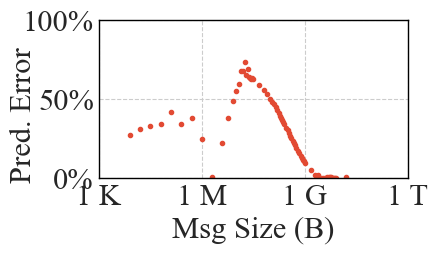

In [ ]:
# use last chunk's T0 as the total communication time to calculate the G, only use the G to predict the latency when only consider the inter node latency.

gpus_per_node = 8
chunk_size = 0.5 # MB
number_channels = 16

#first chunk data copy/reduce time + first chunk communication time + addtional chunks communication time
df_sweep_data_simple_tree_v1 = df_sweep_data_simple_tree.with_columns([
    (pl.when(pl.col("msg") < 1048576)
     .then(
         # Small message case
         ((pl.min_horizontal(chunk_size*number_channels, pl.col("msg")/1e6) * 1e3 * 
           ((G_rrs_reverse_small + G_rcs_reverse_small) * (pl.col("nnodes").log(2)-1) + G_send_reverse_small + G_rrcs_reverse_small)) 
          + L_send_small + (pl.col("nnodes").log(2)-1) * (L_rrs_small + L_rcs_small) + L_rrcs_small
          + (pl.min_horizontal(chunk_size*number_channels, pl.col("msg")/1e6) * 1e3 * 
             ((G_reverse_reduce_copy_rrs_small + G_reverse_reduce_copy_rcs_small) * (pl.col("nnodes").log(2)-1) + G_reverse_reduce_copy_send_small + G_reverse_reduce_copy_rrcs_small))
          + L_reduce_copy_send_small + (pl.col("nnodes").log(2)-1) * (L_reduce_copy_rrs_small + L_reduce_copy_rcs_small) + L_reduce_copy_rrcs_small
          + pl.max_horizontal(pl.col("msg")/1e6 - number_channels * chunk_size, 0) * 1e3 / G_small)
     )
     .otherwise(
         # Large message case
         ((pl.min_horizontal(chunk_size*number_channels, pl.col("msg")/1e6) * 1e3 * 
           ((G_rrs_reverse_large + G_rcs_reverse_large) * (pl.col("nnodes").log(2)-1) + G_send_reverse_large + G_rrcs_reverse_large)) 
          + L_send_large + (pl.col("nnodes").log(2)-1) * (L_rrs_large + L_rcs_large) + L_rrcs_large
          + (pl.min_horizontal(chunk_size*number_channels, pl.col("msg")/1e6) * 1e3 * 
             ((G_reverse_reduce_copy_rrs_large + G_reverse_reduce_copy_rcs_large) * (pl.col("nnodes").log(2)-1) + G_reverse_reduce_copy_send_large + G_reverse_reduce_copy_rrcs_large))
          + L_reduce_copy_send_large + (pl.col("nnodes").log(2)-1) * (L_reduce_copy_rrs_large + L_reduce_copy_rcs_large) + L_reduce_copy_rrcs_large
          + pl.max_horizontal(pl.col("msg")/1e6 - number_channels * chunk_size, 0) * 1e3 / G_large)
     )).alias("latency_pre (us)")
])

# Then, create the bandwidth column using the newly created latency column
df_sweep_data_simple_tree_v1 = df_sweep_data_simple_tree_v1.with_columns([
    (pl.col("msg") * 0.001 * (2*(pl.col("nnodes") * gpus_per_node - 1)/(pl.col("nnodes") * gpus_per_node)) / pl.col("latency_pre (us)")).alias("BW_pre (GB/s)")
])

# Then, create the bandwidth column using the newly created latency column
df_sweep_data_simple_tree_v1_csv = df_sweep_data_simple_tree_v1.with_columns([
    ((pl.col("latency_pre (us)") - pl.col("latency (us)")).abs() * 100 / pl.col("latency (us)")).alias("prediction_error (%)")
])

with pd.option_context('display.max_rows', None, 'display.max_columns', None, 'display.width', 1000):
        print(df_sweep_data_simple_tree_v1_csv.to_pandas())

df_sweep_data_simple_tree_v1_csv.to_pandas().to_csv('model0.csv', index=False)

plot_prediction_error(
    df_sweep_data_simple_tree_v1,
    figsize=(5, 3),
    pdf_filename="allreduce_tree_simple_pre_error_v1.pdf",
    y_ticks=[0.0, 0.50, 1.00],
    y_labels=["0%", "50%", "100%"],
    xlabel="Msg Size (B)",
    ylabel="Pred. Error",
    legend=False
)

📄 Plot saved to: allreduce_tree_simple_pre_comparison_v1.pdf


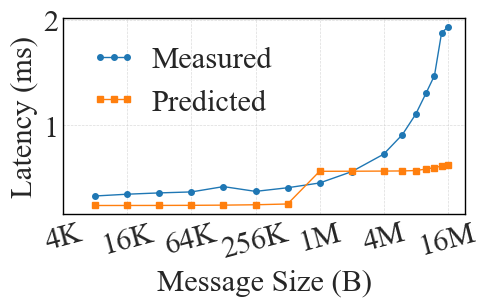

In [135]:
plot_latency_comparison(
    df=df_sweep_data_simple_tree_v1,
    y_cols=['latency (us)', 'latency_pre (us)'],
    labels=['Measured', 'Predicted'],
    markers=['o', 's'],
    colors=['#1f77b4', '#ff7f0e'],
    xlabel='Message Size (B)',
    ylabel='Latency (ms)',
    pdf_filename='allreduce_tree_simple_pre_comparison_v1.pdf' 
)

📄 Plot saved to: allreduce_tree_simple_BW_pre_comparison_v1.pdf


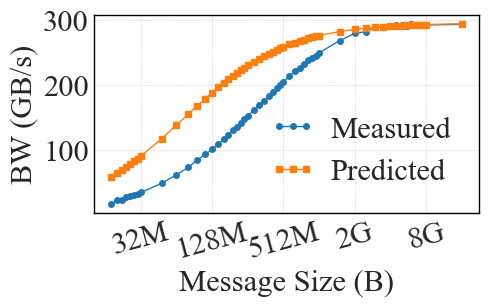

In [136]:
plot_BW_comparison(
    df=df_sweep_data_simple_tree_v1,
    y_cols=['BW (GB/s)', 'BW_pre (GB/s)'],
    labels=['Measured', 'Predicted'],
    markers=['o', 's'],
    colors=['#1f77b4', '#ff7f0e'],
    xlabel='Message Size (B)',
    ylabel='BW (GB/s)',
    pdf_filename='allreduce_tree_simple_BW_pre_comparison_v1.pdf' 
)

In [137]:
df_sweep_data_simple_tree = df_sweep_data_means.filter(
    (pl.col("algorithm") == "tree") & 
    (pl.col("protocol") == "simple") & 
    (pl.col("msg") == 17179869184) &
    (pl.col("nnodes") > 2) 
)

print(df_sweep_data_simple_tree)

shape: (8, 6)
┌─────────────┬────────┬───────────┬──────────┬───────────────┬────────────┐
│ msg         ┆ nnodes ┆ algorithm ┆ protocol ┆ latency (us)  ┆ BW (GB/s)  │
│ ---         ┆ ---    ┆ ---       ┆ ---      ┆ ---           ┆ ---        │
│ i64         ┆ i64    ┆ str       ┆ str      ┆ f64           ┆ f64        │
╞═════════════╪════════╪═══════════╪══════════╪═══════════════╪════════════╡
│ 17179869184 ┆ 4      ┆ tree      ┆ simple   ┆ 115524.333333 ┆ 288.13     │
│ 17179869184 ┆ 8      ┆ tree      ┆ simple   ┆ 115569.666667 ┆ 292.663333 │
│ 17179869184 ┆ 16     ┆ tree      ┆ simple   ┆ 116366.333333 ┆ 292.966667 │
│ 17179869184 ┆ 32     ┆ tree      ┆ simple   ┆ 115940.666667 ┆ 295.2      │
│ 17179869184 ┆ 48     ┆ tree      ┆ simple   ┆ 116589.0      ┆ 293.95     │
│ 17179869184 ┆ 64     ┆ tree      ┆ simple   ┆ 117968.333333 ┆ 290.703333 │
│ 17179869184 ┆ 96     ┆ tree      ┆ simple   ┆ 116583.666667 ┆ 294.35     │
│ 17179869184 ┆ 128    ┆ tree      ┆ simple   ┆ 115863.333333 

           msg  nnodes algorithm protocol   latency (us)   BW (GB/s)  latency_pre (us)  BW_pre (GB/s)  prediction_error (%)
0  17179869184       4      tree   simple  115524.333333  288.130000     115846.133036     287.329371              0.278556
1  17179869184       8      tree   simple  115569.666667  292.663333     116009.612703     291.552283              0.380676
2  17179869184      16      tree   simple  116366.333333  292.966667     116173.092370     293.452659              0.166063
3  17179869184      32      tree   simple  115940.666667  295.200000     116336.572037     294.193993              0.341472
4  17179869184      48      tree   simple  116589.000000  293.950000     116432.201512     294.336613              0.134488
5  17179869184      64      tree   simple  117968.333333  290.703333     116500.051705     294.357204              1.244640
6  17179869184      96      tree   simple  116583.666667  294.350000     116595.681180     294.307635              0.010305
7  17179

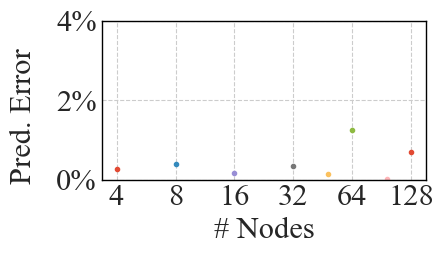

In [ ]:
# use last chunk's T0 as the total communication time to calculate the G, only use the G to predict the latency when only consider the inter node latency.

gpus_per_node = 8
chunk_size = 0.5 # MB
number_channels = 16

df_sweep_data_simple_tree_v1 = df_sweep_data_simple_tree.with_columns([
    (pl.when(pl.col("msg") < 1048576)
     .then(
         # Small message case
         ((pl.min_horizontal(chunk_size*number_channels, pl.col("msg")/1e6) * 1e3 * 
           ((G_rrs_reverse_small + G_rcs_reverse_small) * (pl.col("nnodes").log(2)-1) + G_send_reverse_small + G_rrcs_reverse_small)) 
          + L_send_small + (pl.col("nnodes").log(2)-1) * (L_rrs_small + L_rcs_small) + L_rrcs_small
          + (pl.min_horizontal(chunk_size*number_channels, pl.col("msg")/1e6) * 1e3 * 
             ((G_reverse_reduce_copy_rrs_small + G_reverse_reduce_copy_rcs_small) * (pl.col("nnodes").log(2)-1) + G_reverse_reduce_copy_send_small + G_reverse_reduce_copy_rrcs_small))
          + L_reduce_copy_send_small + (pl.col("nnodes").log(2)-1) * (L_reduce_copy_rrs_small + L_reduce_copy_rcs_small) + L_reduce_copy_rrcs_small
          + pl.max_horizontal(pl.col("msg")/1e6 - number_channels * chunk_size, 0) * 1e3 / G_small)
     )
     .otherwise(
         # Large message case
         ((pl.min_horizontal(chunk_size*number_channels, pl.col("msg")/1e6) * 1e3 * 
           ((G_rrs_reverse_large + G_rcs_reverse_large) * (pl.col("nnodes").log(2)-1) + G_send_reverse_large + G_rrcs_reverse_large)) 
          + L_send_large + (pl.col("nnodes").log(2)-1) * (L_rrs_large + L_rcs_large) + L_rrcs_large
          + (pl.min_horizontal(chunk_size*number_channels, pl.col("msg")/1e6) * 1e3 * 
             ((G_reverse_reduce_copy_rrs_large + G_reverse_reduce_copy_rcs_large) * (pl.col("nnodes").log(2)-1) + G_reverse_reduce_copy_send_large + G_reverse_reduce_copy_rrcs_large))
          + L_reduce_copy_send_large + (pl.col("nnodes").log(2)-1) * (L_reduce_copy_rrs_large + L_reduce_copy_rcs_large) + L_reduce_copy_rrcs_large
          + pl.max_horizontal(pl.col("msg")/1e6 - number_channels * chunk_size, 0) * 1e3 / G_large)
     )).alias("latency_pre (us)")
])

# Then, create the bandwidth column using the newly created latency column
df_sweep_data_simple_tree_v1 = df_sweep_data_simple_tree_v1.with_columns([
    (pl.col("msg") * 0.001 * (2*(pl.col("nnodes") * gpus_per_node - 1)/(pl.col("nnodes") * gpus_per_node)) / pl.col("latency_pre (us)")).alias("BW_pre (GB/s)")
])

# Then, create the bandwidth column using the newly created latency column
df_sweep_data_simple_tree_v1_csv = df_sweep_data_simple_tree_v1.with_columns([
    ((pl.col("latency_pre (us)") - pl.col("latency (us)")).abs() * 100 / pl.col("latency (us)")).alias("prediction_error (%)")
])

with pd.option_context('display.max_rows', None, 'display.max_columns', None, 'display.width', 1000):
        print(df_sweep_data_simple_tree_v1_csv.to_pandas())

df_sweep_data_simple_tree_v1_csv.to_pandas().to_csv('model0.csv', index=False)

plot_prediction_error_nodes(
    df_sweep_data_simple_tree_v1,
    figsize=(5, 3),
    pdf_filename="allreduce_tree_simple_pre_error_v1_nodes.pdf",
    y_ticks=[0.0, 0.02, 0.04],
    y_labels=["0%", "2%", "4%"],
    xlabel="# Nodes",
    ylabel="Pred. Error",
    legend=False
)

📄 Plot saved to: allreduce_tree_simple_pre_comparison_v1_nodes.pdf


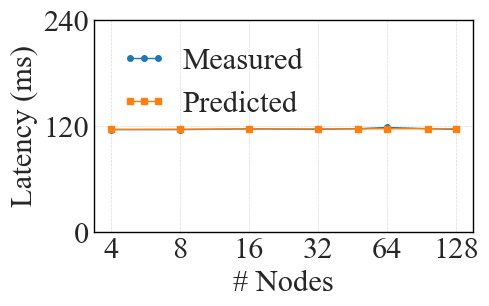

In [139]:
plot_latency_comparison_nodes(
    df=df_sweep_data_simple_tree_v1,
    y_cols=['latency (us)', 'latency_pre (us)'],
    labels=['Measured', 'Predicted'],
    markers=['o', 's'],
    colors=['#1f77b4', '#ff7f0e'],
    xlabel='# Nodes',
    ylabel='Latency (ms)',
    pdf_filename='allreduce_tree_simple_pre_comparison_v1_nodes.pdf' 
)

### LL, Tree

In [140]:
# Read from sweep data

df_sweep_data_ll_tree = df_sweep_data_means.filter(
    (pl.col("algorithm") == "tree") & 
    (pl.col("protocol") == "ll") & 
    (pl.col("nnodes") == 16)
)

print(df_sweep_data_ll_tree)

shape: (38, 6)
┌───────────┬────────┬───────────┬──────────┬──────────────┬───────────┐
│ msg       ┆ nnodes ┆ algorithm ┆ protocol ┆ latency (us) ┆ BW (GB/s) │
│ ---       ┆ ---    ┆ ---       ┆ ---      ┆ ---          ┆ ---       │
│ i64       ┆ i64    ┆ str       ┆ str      ┆ f64          ┆ f64       │
╞═══════════╪════════╪═══════════╪══════════╪══════════════╪═══════════╡
│ 8192      ┆ 16     ┆ tree      ┆ ll       ┆ 238.133333   ┆ 0.066667  │
│ 16384     ┆ 16     ┆ tree      ┆ ll       ┆ 220.0        ┆ 0.15      │
│ 32768     ┆ 16     ┆ tree      ┆ ll       ┆ 217.866667   ┆ 0.3       │
│ 65536     ┆ 16     ┆ tree      ┆ ll       ┆ 216.4        ┆ 0.6       │
│ 131072    ┆ 16     ┆ tree      ┆ ll       ┆ 221.466667   ┆ 1.176667  │
│ …         ┆ …      ┆ …         ┆ …        ┆ …            ┆ …         │
│ 201326592 ┆ 16     ┆ tree      ┆ ll       ┆ 12037.333333 ┆ 33.193333 │
│ 218103808 ┆ 16     ┆ tree      ┆ ll       ┆ 13015.333333 ┆ 33.256667 │
│ 234881024 ┆ 16     ┆ tree      ┆ l

In [141]:
# Read from profiling

# === File Paths ===
profiling_files_LL = {
    "r0": "/Users/liuyaod/daily_report/AllReduce-Tree/LL_profiling_results/nccl_allreduce_heo-inter_r-0.out",
    "r8": "/Users/liuyaod/daily_report/AllReduce-Tree/LL_profiling_results/nccl_allreduce_heo-inter_r-8.out",
    "r16": "/Users/liuyaod/daily_report/AllReduce-Tree/LL_profiling_results/nccl_allreduce_heo-inter_r-16.out",
    "r17": "/Users/liuyaod/daily_report/AllReduce-Tree/LL_profiling_results/nccl_allreduce_heo-inter_r-17.out",
    "r24": "/Users/liuyaod/daily_report/AllReduce-Tree/LL_profiling_results/nccl_allreduce_heo-inter_r-24.out",
}

# === Load Data ===
df_r0_LL = parse_send_timings(profiling_files_LL["r0"])
df_r8_LL = parse_send_timings(profiling_files_LL["r8"])
df_r16_LL = parse_send_timings(profiling_files_LL["r16"])
df_r17_LL = parse_send_timings(profiling_files_LL["r17"])
df_r24_LL = parse_send_timings(profiling_files_LL["r24"])

df_r16_up_LL = df_r16_LL.filter(pl.col("dest") == 0)

df_r16_down_LL = df_r16_LL.filter(pl.col("dest") == 24)

with pd.option_context('display.max_rows', None, 'display.max_columns', None, 'display.width', 1000):
        print(df_r16_up_LL.to_pandas())


Number of records: 139
Number of records: 139
Number of records: 278
Number of records: 139
Number of records: 139
     chunk_id  channel  source  dest  algo protocol  message_size  nchannels  nmessages  iteration        T1        T2        T9        T8       T_init         T0        T7        T10
0           0        0      16     0  TREE       LL             8          2      10000          0  0.013873  0.072280  0.096741  0.060281  3369.954590   0.000000  0.023485   0.082869
1           0        0      16     0  TREE       LL            16          4      10000          0  0.015349  0.061118  0.085511  0.075858  3291.298584   0.000000  0.023450   0.070164
2           0        0      16     0  TREE       LL            32          8      10000          0  0.016059  0.057265  0.082983  0.082847  3246.511719   0.000000  0.024840   0.066924
3           0        0      16     0  TREE       LL            64         16      10000          0  0.020803  0.052030  0.077327  0.104427  3156.6152

In [142]:
# Use the function
# Usage:
results = analyze_all_L_G_timings(df_r24_LL, df_r16_up_LL, df_r0_LL, df_r16_down_LL, 1, 32, 64, 512)

# Large message results
G_send_reverse_large_LL = results['G_send_reverse_large']
L_send_large_LL = results['L_send_large']

G_rrs_reverse_large_LL = results['G_rrs_reverse_large']
L_rrs_large_LL = results['L_rrs_large']

G_rrcs_reverse_large_LL = results['G_rrcs_reverse_large']
L_rrcs_large_LL = results['L_rrcs_large']

G_rcs_reverse_large_LL = results['G_rcs_reverse_large']
L_rcs_large_LL = results['L_rcs_large']

# Small message results
G_send_reverse_small_LL = results['G_send_reverse_small']
L_send_small_LL = results['L_send_small']

G_rrs_reverse_small_LL = results['G_rrs_reverse_small']
L_rrs_small_LL = results['L_rrs_small']

G_rrcs_reverse_small_LL = results['G_rrcs_reverse_small']
L_rrcs_small_LL = results['L_rrcs_small']

G_rcs_reverse_small_LL = results['G_rcs_reverse_small']
L_rcs_small_LL = results['L_rcs_small']

G_reverse = 0.032 (us/KB), L (us) = 29.703, R-squared value is 0.627112
G_reverse = 0.010 (us/KB), L (us) = 28.581, R-squared value is 0.331081
G_reverse = 0.012 (us/KB), L (us) = 24.543, R-squared value is 0.941589
G_reverse = 0.018 (us/KB), L (us) = 23.394, R-squared value is 0.917256
G_reverse = 0.022 (us/KB), L (us) = 23.920, R-squared value is 0.369233
G_reverse = 0.057 (us/KB), L (us) = 23.799, R-squared value is 0.863067
G_reverse = 0.007 (us/KB), L (us) = 22.988, R-squared value is 0.535358
G_reverse = -0.020 (us/KB), L (us) = 23.634, R-squared value is 0.430837


In [143]:
# Usage:
results = analyze_all_copy_timings(df_r16_up_LL, df_r24_LL, df_r17_LL, df_r0_LL, 1, 32, 64, 512)

# Access all results:
# Large message results
G_reverse_reduce_copy_rrs_large_LL = results['G_reverse_reduce_copy_rrs_large']
L_reduce_copy_rrs_large_LL = results['L_reduce_copy_rrs_large']

G_reverse_reduce_copy_rcs_large_LL = results['G_reverse_reduce_copy_rcs_large']
L_reduce_copy_rcs_large_LL = results['L_reduce_copy_rcs_large']

G_reverse_reduce_copy_send_large_LL = results['G_reverse_reduce_copy_send_large']
L_reduce_copy_send_large_LL = results['L_reduce_copy_send_large']

G_reverse_reduce_copy_rrcs_large_LL = results['G_reverse_reduce_copy_rrcs_large']
L_reduce_copy_rrcs_large_LL = results['L_reduce_copy_rrcs_large']

# Small message results
G_reverse_reduce_copy_rrs_small_LL = results['G_reverse_reduce_copy_rrs_small']
L_reduce_copy_rrs_small_LL = results['L_reduce_copy_rrs_small']

G_reverse_reduce_copy_rcs_small_LL = results['G_reverse_reduce_copy_rcs_small']
L_reduce_copy_rcs_small_LL = results['L_reduce_copy_rcs_small']

G_reverse_reduce_copy_send_small_LL = results['G_reverse_reduce_copy_send_small']
L_reduce_copy_send_small_LL = results['L_reduce_copy_send_small']

G_reverse_reduce_copy_rrcs_small_LL = results['G_reverse_reduce_copy_rrcs_small']
L_reduce_copy_rrcs_small_LL = results['L_reduce_copy_rrcs_small']

G = -0.003 (us/KB), L (us) = 1.444, R-squared value is 0.016345
G = -0.009 (us/KB), L (us) = 54.801, R-squared value is 0.089342
G = 0.006 (us/KB), L (us) = 3.242, R-squared value is 0.771779
G = 0.012 (us/KB), L (us) = -5.031, R-squared value is 0.109602
G = -0.723 (us/KB), L (us) = 34.387, R-squared value is 0.855568
G = 0.566 (us/KB), L (us) = 22.833, R-squared value is 0.894423
G = 0.046 (us/KB), L (us) = 2.381, R-squared value is 0.983308
G = 0.222 (us/KB), L (us) = 4.930, R-squared value is 0.563203


In [144]:
import statistics

message_size_for_G = 262144

chunk_size_LL = 0.03125

# Option 1: Using a list of dataframes
dataframes = [df_r0_LL, df_r8_LL, df_r16_up_LL, df_r16_down_LL, df_r17_LL, df_r24_LL]
G_LL_large, G_LL_small = analyze_chunk_speeds(dataframes, message_size_for_G, chunk_size_LL, 64, 64)

print(f"the G_LL_large for the tree is {G_LL_large: 3f} GB/s")
print(f"the G_LL_small for the tree is {G_LL_small: 3f} GB/s")

the G_LL_large for the tree is  17.611857 GB/s
the G_LL_small for the tree is  17.456882 GB/s


          msg  nnodes algorithm protocol  latency (us)  BW (GB/s)  latency_pre (us)  BW_pre (GB/s)  prediction_error (%)
0        8192      16      tree       ll    238.133333   0.066667        190.338287       0.085406             20.070708
1       16384      16      tree       ll    220.000000   0.150000        191.472075       0.169800             12.967239
2       32768      16      tree       ll    217.866667   0.300000        193.739650       0.335626             11.074212
3       65536      16      tree       ll    216.400000   0.600000        218.506343       0.595168              0.973356
4      131072      16      tree       ll    221.466667   1.176667        226.840971       1.146601              2.426688
5      262144      16      tree       ll    251.033333   2.070000        243.510229       2.136222              2.996855
6      524288      16      tree       ll    307.066667   3.390000        275.138955       3.781304             10.397648
7     1048576      16      tree 

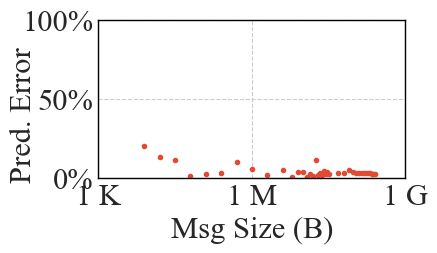

In [145]:
# use last chunk's T0 as the total communication time to calculate the G, only use the G to predict the latency when only consider the inter node latency.

number_nodes = 16
gpus_per_node = 8
chunk_size_LL = 0.03125 # MB
number_channels = 16

# In the LL protocol, I discovered that the reduce/copy time for the first chunk is not needed, 
# as LL protocol appears to skip this operation. 
# In contrast, the Simple protocol requires this operation, 
# as evidenced by the reduceCopy() function in primitives_simple.h.
df_sweep_data_ll_tree_v1 = df_sweep_data_ll_tree.with_columns([
    (pl.when(pl.col("msg") < 65536)
     .then(
         # Small message case
         ((pl.min_horizontal(chunk_size_LL*number_channels, pl.col("msg")/1e6) * 1e3 * 
           ((G_rrs_reverse_small_LL + G_rcs_reverse_small_LL) * (pl.col("nnodes").log(2)-1) + G_send_reverse_small_LL + G_rrcs_reverse_small_LL)) 
          + L_send_small_LL + (pl.col("nnodes").log(2)-1) * (L_rrs_small_LL + L_rcs_small_LL) + L_rrcs_small_LL
          + pl.max_horizontal(pl.col("msg")/1e6 - number_channels * chunk_size_LL, 0) * 1e3 / G_LL_small)
     )
     .otherwise(
         # Large message case
         ((pl.min_horizontal(chunk_size_LL*number_channels, pl.col("msg")/1e6) * 1e3 * 
           ((G_rrs_reverse_large_LL + G_rcs_reverse_large_LL) * (pl.col("nnodes").log(2)-1) + G_send_reverse_large_LL + G_rrcs_reverse_large_LL)) 
          + L_send_large_LL + (pl.col("nnodes").log(2)-1) * (L_rrs_large_LL + L_rcs_large_LL) + L_rrcs_large_LL
          + pl.max_horizontal(pl.col("msg")/1e6 - number_channels * chunk_size_LL, 0) * 1e3 / G_LL_large)
     )).alias("latency_pre (us)")
])

# Then, create the bandwidth column using the newly created latency column
df_sweep_data_ll_tree_v1 = df_sweep_data_ll_tree_v1.with_columns([
    (pl.col("msg") * 0.001 * (2*(pl.col("nnodes") * gpus_per_node - 1)/(pl.col("nnodes") * gpus_per_node)) / pl.col("latency_pre (us)")).alias("BW_pre (GB/s)")
])

# Then, create the bandwidth column using the newly created latency column
df_sweep_data_ll_tree_v1_csv = df_sweep_data_ll_tree_v1.with_columns([
    ((pl.col("latency_pre (us)") - pl.col("latency (us)")).abs() * 100 / pl.col("latency (us)")).alias("prediction_error (%)")
])

with pd.option_context('display.max_rows', None, 'display.max_columns', None, 'display.width', 1000):
        print(df_sweep_data_ll_tree_v1_csv.to_pandas())

df_sweep_data_ll_tree_v1_csv.to_pandas().to_csv('model0.csv', index=False)

plot_prediction_error(
    df_sweep_data_ll_tree_v1,
    figsize=(5, 3),
    pdf_filename="allreduce_tree_LL_pre_error_v1.pdf",
    y_ticks=[0.0, 0.50, 1.00],
    y_labels=["0%", "50%", "100%"],
    xlabel="Msg Size (B)",
    ylabel="Pred. Error",
    legend=False,
    protocol="LL"
)

📄 Plot saved to: allreduce_tree_LL_pre_comparison_v1.pdf


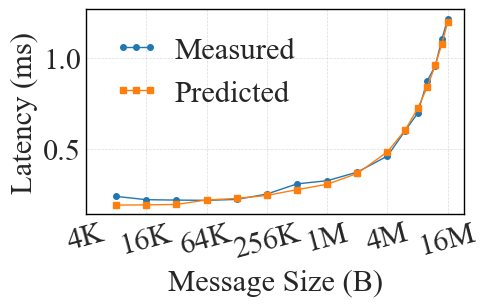

In [146]:
plot_latency_comparison(
    df=df_sweep_data_ll_tree_v1,
    y_cols=['latency (us)', 'latency_pre (us)'],
    labels=['Measured', 'Predicted'],
    markers=['o', 's'],
    colors=['#1f77b4', '#ff7f0e'],
    xlabel='Message Size (B)',
    ylabel='Latency (ms)',
    pdf_filename='allreduce_tree_LL_pre_comparison_v1.pdf' 
)

📄 Plot saved to: allreduce_tree_LL_BW_pre_comparison_v1.pdf


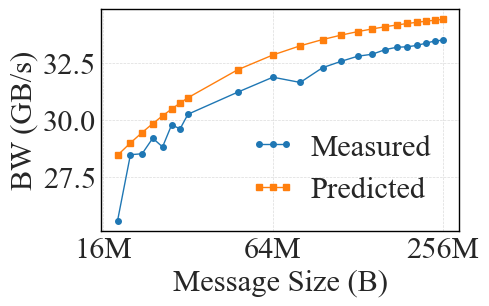

In [147]:
plot_BW_comparison(
    df=df_sweep_data_ll_tree_v1,
    y_cols=['BW (GB/s)', 'BW_pre (GB/s)'],
    labels=['Measured', 'Predicted'],
    markers=['o', 's'],
    colors=['#1f77b4', '#ff7f0e'],
    xlabel='Message Size (B)',
    ylabel='BW (GB/s)',
    pdf_filename='allreduce_tree_LL_BW_pre_comparison_v1.pdf',
    protocol="LL"
)

In [148]:
df_sweep_data_ll_tree = df_sweep_data_means.filter(
    (pl.col("algorithm") == "tree") & 
    (pl.col("protocol") == "ll") & 
    (pl.col("msg") == 268435456) &
    (pl.col("nnodes") > 2) 
)

print(df_sweep_data_ll_tree)

shape: (8, 6)
┌───────────┬────────┬───────────┬──────────┬──────────────┬───────────┐
│ msg       ┆ nnodes ┆ algorithm ┆ protocol ┆ latency (us) ┆ BW (GB/s) │
│ ---       ┆ ---    ┆ ---       ┆ ---      ┆ ---          ┆ ---       │
│ i64       ┆ i64    ┆ str       ┆ str      ┆ f64          ┆ f64       │
╞═══════════╪════════╪═══════════╪══════════╪══════════════╪═══════════╡
│ 268435456 ┆ 4      ┆ tree      ┆ ll       ┆ 15314.333333 ┆ 33.96     │
│ 268435456 ┆ 8      ┆ tree      ┆ ll       ┆ 15894.666667 ┆ 33.26     │
│ 268435456 ┆ 16     ┆ tree      ┆ ll       ┆ 15909.333333 ┆ 33.483333 │
│ 268435456 ┆ 32     ┆ tree      ┆ ll       ┆ 15913.0      ┆ 33.61     │
│ 268435456 ┆ 48     ┆ tree      ┆ ll       ┆ 16045.0      ┆ 33.376667 │
│ 268435456 ┆ 64     ┆ tree      ┆ ll       ┆ 16149.0      ┆ 33.19     │
│ 268435456 ┆ 96     ┆ tree      ┆ ll       ┆ 16753.333333 ┆ 32.063333 │
│ 268435456 ┆ 128    ┆ tree      ┆ ll       ┆ 16116.666667 ┆ 33.276667 │
└───────────┴────────┴───────────┴───

         msg  nnodes algorithm protocol  latency (us)  BW (GB/s)  latency_pre (us)  BW_pre (GB/s)  prediction_error (%)
0  268435456       4      tree       ll  15314.333333  33.960000      15355.510818      33.870166              0.268882
1  268435456       8      tree       ll  15894.666667  33.260000      15421.313378      34.269604              2.978064
2  268435456      16      tree       ll  15909.333333  33.483333      15487.115937      34.394823              2.653897
3  268435456      32      tree       ll  15913.000000  33.610000      15552.918497      34.384142              2.262813
4  268435456      48      tree       ll  16045.000000  33.376667      15591.410527      34.344090              2.826983
5  268435456      64      tree       ll  16149.000000  33.190000      15618.721056      34.306416              3.283664
6  268435456      96      tree       ll  16753.333333  32.063333      15657.213086      34.244400              6.542699
7  268435456     128      tree       ll 

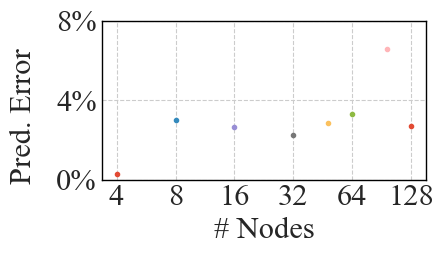

In [149]:
# use last chunk's T0 as the total communication time to calculate the G, only use the G to predict the latency when only consider the inter node latency.

gpus_per_node = 8
chunk_size_LL = 0.03125 # MB
number_channels = 16

# In the LL protocol, I discovered that the reduce/copy time for the first chunk is not needed, 
# as LL protocol appears to skip this operation. 
# In contrast, the Simple protocol requires this operation, 
# as evidenced by the reduceCopy() function in primitives_simple.h.
df_sweep_data_ll_tree_v1 = df_sweep_data_ll_tree.with_columns([
    (pl.when(pl.col("msg") < 65536)
     .then(
         # Small message case
         ((pl.min_horizontal(chunk_size_LL*number_channels, pl.col("msg")/1e6) * 1e3 * 
           ((G_rrs_reverse_small_LL + G_rcs_reverse_small_LL) * (pl.col("nnodes").log(2)-1) + G_send_reverse_small_LL + G_rrcs_reverse_small_LL)) 
          + L_send_small_LL + (pl.col("nnodes").log(2)-1) * (L_rrs_small_LL + L_rcs_small_LL) + L_rrcs_small_LL
          + pl.max_horizontal(pl.col("msg")/1e6 - number_channels * chunk_size_LL, 0) * 1e3 / G_LL_small)
     )
     .otherwise(
         # Large message case
         ((pl.min_horizontal(chunk_size_LL*number_channels, pl.col("msg")/1e6) * 1e3 * 
           ((G_rrs_reverse_large_LL + G_rcs_reverse_large_LL) * (pl.col("nnodes").log(2)-1) + G_send_reverse_large_LL + G_rrcs_reverse_large_LL)) 
          + L_send_large_LL + (pl.col("nnodes").log(2)-1) * (L_rrs_large_LL + L_rcs_large_LL) + L_rrcs_large_LL
          + pl.max_horizontal(pl.col("msg")/1e6 - number_channels * chunk_size_LL, 0) * 1e3 / G_LL_large)
     )).alias("latency_pre (us)")
])

# Then, create the bandwidth column using the newly created latency column
df_sweep_data_ll_tree_v1 = df_sweep_data_ll_tree_v1.with_columns([
    (pl.col("msg") * 0.001 * (2*(pl.col("nnodes") * gpus_per_node - 1)/(pl.col("nnodes") * gpus_per_node)) / pl.col("latency_pre (us)")).alias("BW_pre (GB/s)")
])

# Then, create the bandwidth column using the newly created latency column
df_sweep_data_ll_tree_v1_csv = df_sweep_data_ll_tree_v1.with_columns([
    ((pl.col("latency_pre (us)") - pl.col("latency (us)")).abs() * 100 / pl.col("latency (us)")).alias("prediction_error (%)")
])

with pd.option_context('display.max_rows', None, 'display.max_columns', None, 'display.width', 1000):
        print(df_sweep_data_ll_tree_v1_csv.to_pandas())

df_sweep_data_ll_tree_v1_csv.to_pandas().to_csv('model0.csv', index=False)

plot_prediction_error_nodes(
    df_sweep_data_ll_tree_v1,
    figsize=(5, 3),
    pdf_filename="allreduce_tree_LL_pre_error_v1_nodes.pdf",
    y_ticks=[0.0, 0.04, 0.08],
    y_labels=["0%", "4%", "8%"],
    xlabel="# Nodes",
    ylabel="Pred. Error",
    legend=False
)

📄 Plot saved to: allreduce_tree_ll_pre_comparison_v1_nodes.pdf


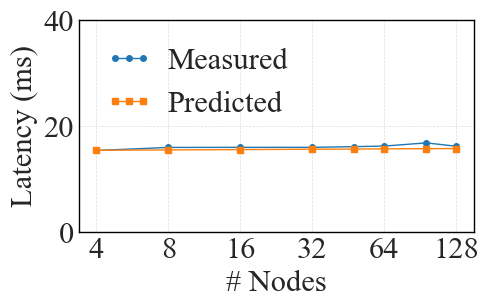

In [150]:
plot_latency_comparison_nodes(
    df=df_sweep_data_ll_tree_v1,
    y_cols=['latency (us)', 'latency_pre (us)'],
    labels=['Measured', 'Predicted'],
    markers=['o', 's'],
    colors=['#1f77b4', '#ff7f0e'],
    xlabel='# Nodes',
    ylabel='Latency (ms)',
    pdf_filename='allreduce_tree_ll_pre_comparison_v1_nodes.pdf',
    protocol="LL"
)

### LL128, TREE

In [151]:
# Read from sweep data

df_sweep_data_ll128_tree = df_sweep_data_means.filter(
    (pl.col("algorithm") == "tree") & 
    (pl.col("protocol") == "ll128") & 
    (pl.col("nnodes") == 16)
)

print(df_sweep_data_ll128_tree)

shape: (69, 6)
┌─────────────┬────────┬───────────┬──────────┬──────────────┬────────────┐
│ msg         ┆ nnodes ┆ algorithm ┆ protocol ┆ latency (us) ┆ BW (GB/s)  │
│ ---         ┆ ---    ┆ ---       ┆ ---      ┆ ---          ┆ ---        │
│ i64         ┆ i64    ┆ str       ┆ str      ┆ f64          ┆ f64        │
╞═════════════╪════════╪═══════════╪══════════╪══════════════╪════════════╡
│ 8192        ┆ 16     ┆ tree      ┆ ll128    ┆ 702.866667   ┆ 0.02       │
│ 16384       ┆ 16     ┆ tree      ┆ ll128    ┆ 261.6        ┆ 0.125      │
│ 32768       ┆ 16     ┆ tree      ┆ ll128    ┆ 231.8        ┆ 0.283333   │
│ 65536       ┆ 16     ┆ tree      ┆ ll128    ┆ 232.2        ┆ 0.56       │
│ 131072      ┆ 16     ┆ tree      ┆ ll128    ┆ 236.733333   ┆ 1.103333   │
│ …           ┆ …      ┆ …         ┆ …        ┆ …            ┆ …          │
│ 6979321856  ┆ 16     ┆ tree      ┆ ll128    ┆ 61402.666667 ┆ 225.553333 │
│ 7516192768  ┆ 16     ┆ tree      ┆ ll128    ┆ 66053.333333 ┆ 225.8     

In [152]:
# Read from profiling

# === File Paths ===
profiling_files_LL128 = {
    "r0": "/Users/liuyaod/daily_report/AllReduce-Tree/LL128_profiling_results/nccl_allreduce_heo-inter_r-0.out",
    "r8": "/Users/liuyaod/daily_report/AllReduce-Tree/LL128_profiling_results/nccl_allreduce_heo-inter_r-8.out",
    "r16": "/Users/liuyaod/daily_report/AllReduce-Tree/LL128_profiling_results/nccl_allreduce_heo-inter_r-16.out",
    "r17": "/Users/liuyaod/daily_report/AllReduce-Tree/LL128_profiling_results/nccl_allreduce_heo-inter_r-17.out",
    "r24": "/Users/liuyaod/daily_report/AllReduce-Tree/LL128_profiling_results/nccl_allreduce_heo-inter_r-24.out",
}

# === Load Data ===
df_r0_LL128 = parse_send_timings(profiling_files_LL128["r0"])
df_r8_LL128 = parse_send_timings(profiling_files_LL128["r8"])
df_r16_LL128 = parse_send_timings(profiling_files_LL128["r16"])
df_r17_LL128 = parse_send_timings(profiling_files_LL128["r17"])
df_r24_LL128 = parse_send_timings(profiling_files_LL128["r24"])

df_r16_up_LL128 = df_r16_LL128.filter(pl.col("dest") == 0)

df_r16_down_LL128 = df_r16_LL128.filter(pl.col("dest") == 24)

with pd.option_context('display.max_rows', None, 'display.max_columns', None, 'display.width', 1000):
        print(df_r16_up_LL128.to_pandas())


Number of records: 225
Number of records: 225
Number of records: 450
Number of records: 225
Number of records: 225
     chunk_id  channel  source  dest  algo protocol  message_size  nchannels  nmessages  iteration        T1        T2        T9        T8       T_init         T0        T7        T10
0           0        0      16     0  TREE    LL128             8          1      10000          0  0.019239  0.057814  0.084105  0.076664  3305.329590   0.000000  0.025315   0.064866
1           0        0      16     0  TREE    LL128            16          2      10000          0  0.017040  0.070804  0.097394  0.072111  3234.641357   0.000000  0.025597   0.080355
2           0        0      16     0  TREE    LL128            32          4      10000          0  0.014187  0.088308  0.114013  0.077285  3302.854736   0.000000  0.024801   0.099826
3           0        0      16     0  TREE    LL128            64          8      10000          0  0.017171  0.066699  0.092551  0.096938  3245.6250

In [153]:

# Usage:
results = analyze_all_L_G_timings(df_r24_LL128, df_r16_up_LL128, df_r0_LL128, df_r16_down_LL128, 1, 64, 128, 8192)

# Large message results
G_send_reverse_large_LL128 = results['G_send_reverse_large']
L_send_large_LL128 = results['L_send_large']

G_rrs_reverse_large_LL128 = results['G_rrs_reverse_large']
L_rrs_large_LL128 = results['L_rrs_large']

G_rrcs_reverse_large_LL128 = results['G_rrcs_reverse_large']
L_rrcs_large_LL128 = results['L_rrcs_large']

G_rcs_reverse_large_LL128 = results['G_rcs_reverse_large']
L_rcs_large_LL128 = results['L_rcs_large']

# Small message results
G_send_reverse_small_LL128 = results['G_send_reverse_small']
L_send_small_LL128 = results['L_send_small']

G_rrs_reverse_small_LL128 = results['G_rrs_reverse_small']
L_rrs_small_LL128 = results['L_rrs_small']

G_rrcs_reverse_small_LL128 = results['G_rrcs_reverse_small']
L_rrcs_small_LL128 = results['L_rrcs_small']

G_rcs_reverse_small_LL128 = results['G_rcs_reverse_small']
L_rcs_small_LL128 = results['L_rcs_small']

G_reverse = 0.000 (us/KB), L (us) = 42.791, R-squared value is 0.000002
G_reverse = 0.001 (us/KB), L (us) = 27.176, R-squared value is 0.562452
G_reverse = 0.001 (us/KB), L (us) = 24.110, R-squared value is 0.922998
G_reverse = 0.002 (us/KB), L (us) = 26.769, R-squared value is 0.608690
G_reverse = -0.046 (us/KB), L (us) = 27.751, R-squared value is 0.513953
G_reverse = -0.011 (us/KB), L (us) = 26.440, R-squared value is 0.452880
G_reverse = 0.003 (us/KB), L (us) = 24.115, R-squared value is 0.224185
G_reverse = 0.004 (us/KB), L (us) = 24.237, R-squared value is 0.071342


In [154]:

# Usage:
results = analyze_all_copy_timings(df_r16_up_LL128, df_r24_LL128, df_r17_LL128, df_r0_LL128, 1, 64, 128, 8192)

# Access all results:
# Large message results
G_reverse_reduce_copy_rrs_large_LL128 = results['G_reverse_reduce_copy_rrs_large']
L_reduce_copy_rrs_large_LL128 = results['L_reduce_copy_rrs_large']

G_reverse_reduce_copy_rcs_large_LL128 = results['G_reverse_reduce_copy_rcs_large']
L_reduce_copy_rcs_large_LL128 = results['L_reduce_copy_rcs_large']

G_reverse_reduce_copy_send_large_LL128 = results['G_reverse_reduce_copy_send_large']
L_reduce_copy_send_large_LL128 = results['L_reduce_copy_send_large']

G_reverse_reduce_copy_rrcs_large_LL128 = results['G_reverse_reduce_copy_rrcs_large']
L_reduce_copy_rrcs_large_LL128 = results['L_reduce_copy_rrcs_large']

# Small message results
G_reverse_reduce_copy_rrs_small_LL128 = results['G_reverse_reduce_copy_rrs_small']
L_reduce_copy_rrs_small_LL128 = results['L_reduce_copy_rrs_small']

G_reverse_reduce_copy_rcs_small_LL128 = results['G_reverse_reduce_copy_rcs_small']
L_reduce_copy_rcs_small_LL128 = results['L_reduce_copy_rcs_small']

G_reverse_reduce_copy_send_small_LL128 = results['G_reverse_reduce_copy_send_small']
L_reduce_copy_send_small_LL128 = results['L_reduce_copy_send_small']

G_reverse_reduce_copy_rrcs_small_LL128 = results['G_reverse_reduce_copy_rrcs_small']
L_reduce_copy_rrcs_small_LL128 = results['L_reduce_copy_rrcs_small']

G = 0.002 (us/KB), L (us) = -13.646, R-squared value is 0.073901
G = 0.001 (us/KB), L (us) = 47.646, R-squared value is 0.039593
G = 0.001 (us/KB), L (us) = 9.218, R-squared value is 0.518136
G = -0.001 (us/KB), L (us) = 5.428, R-squared value is 0.124004
G = 0.172 (us/KB), L (us) = 17.090, R-squared value is 0.066299
G = 0.063 (us/KB), L (us) = 34.109, R-squared value is 0.109896
G = -0.001 (us/KB), L (us) = 5.392, R-squared value is 0.000229
G = 0.127 (us/KB), L (us) = 10.058, R-squared value is 0.105181


In [155]:
import statistics

message_size_for_G = 8388608

chunk_size_LL128 = 0.5487674169 # MB

# Option 1: Using a list of dataframes
dataframes = [df_r0_LL128, df_r8_LL128, df_r16_up_LL128, df_r16_down_LL128, df_r17_LL128, df_r24_LL128]
G_LL128_large, G_LL128_small = analyze_chunk_speeds(dataframes, message_size_for_G, chunk_size_LL128, 64, 64)

print(f"the G_LL128_large for the tree is {G_LL128_large: 3f} GB/s")
print(f"the G_LL128_small for the tree is {G_LL128_small: 3f} GB/s")

the G_LL128_large for the tree is  112.443580 GB/s
the G_LL128_small for the tree is  104.215721 GB/s


            msg  nnodes algorithm protocol   latency (us)   BW (GB/s)  latency_pre (us)  BW_pre (GB/s)  prediction_error (%)
0          8192      16      tree    ll128     702.866667    0.020000        203.359550       0.079937             71.067123
1         16384      16      tree    ll128     261.600000    0.125000        202.820579       0.160299             22.469198
2         32768      16      tree    ll128     231.800000    0.283333        201.742637       0.322312             12.966938
3         65536      16      tree    ll128     232.200000    0.560000        199.586752       0.651586             14.045327
4        131072      16      tree    ll128     236.733333    1.103333        229.883268       1.131426              2.893579
5        262144      16      tree    ll128     244.900000    2.126667        231.032163       2.251600              5.662653
6        524288      16      tree    ll128     251.133333    4.143333        233.329953       4.458853              7.089214


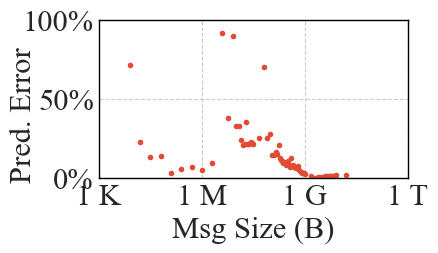

In [156]:
# use last chunk's T0 as the total communication time to calculate the G, only use the G to predict the latency when only consider the inter node latency.

number_nodes = 16
gpus_per_node = 8
chunk_size_LL128 = 0.5487674169 # MB
number_channels = 16

# In the LL128 protocol, I discovered that the reduce/copy time for the first chunk is not needed, 
# as LL128 protocol appears to skip this operation. 
# In contrast, the Simple protocol requires this operation, 
# as evidenced by the reduceCopy() function in primitives_simple.h.
df_sweep_data_ll128_tree_v1 = df_sweep_data_ll128_tree.with_columns([
    (pl.when(pl.col("msg") < 131072)
     .then(
         # Small message case
         ((pl.min_horizontal(chunk_size_LL128*number_channels, pl.col("msg")/1e6) * 1e3 * 
           ((G_rrs_reverse_small_LL128 + G_rcs_reverse_small_LL128) * (pl.col("nnodes").log(2)-1) + G_send_reverse_small_LL128 + G_rrcs_reverse_small_LL128)) 
          + L_send_small_LL128 + (pl.col("nnodes").log(2)-1) * (L_rrs_small_LL128 + L_rcs_small_LL128) + L_rrcs_small_LL128
          + pl.max_horizontal(pl.col("msg")/1e6 - number_channels * chunk_size_LL128, 0) * 1e3 / G_LL128_small)
     )
     .otherwise(
         # Large message case
         ((pl.min_horizontal(chunk_size_LL128*number_channels, pl.col("msg")/1e6) * 1e3 * 
           ((G_rrs_reverse_large_LL128 + G_rcs_reverse_large_LL128) * (pl.col("nnodes").log(2)-1) + G_send_reverse_large_LL128 + G_rrcs_reverse_large_LL128)) 
          + L_send_large_LL128 + (pl.col("nnodes").log(2)-1) * (L_rrs_large_LL128 + L_rcs_large_LL128) + L_rrcs_large_LL128
          + pl.max_horizontal(pl.col("msg")/1e6 - number_channels * chunk_size_LL128, 0) * 1e3 / G_LL128_large)
     )).alias("latency_pre (us)")
])

# Then, create the bandwidth column using the newly created latency column
df_sweep_data_ll128_tree_v1 = df_sweep_data_ll128_tree_v1.with_columns([
    (pl.col("msg") * 0.001 * (2*(pl.col("nnodes") * gpus_per_node - 1)/(pl.col("nnodes") * gpus_per_node)) / pl.col("latency_pre (us)")).alias("BW_pre (GB/s)")
])

# Then, create the bandwidth column using the newly created latency column
df_sweep_data_ll128_tree_v1_csv = df_sweep_data_ll128_tree_v1.with_columns([
    ((pl.col("latency_pre (us)") - pl.col("latency (us)")).abs() * 100 / pl.col("latency (us)")).alias("prediction_error (%)")
])

with pd.option_context('display.max_rows', None, 'display.max_columns', None, 'display.width', 1000):
        print(df_sweep_data_ll128_tree_v1_csv.to_pandas())

df_sweep_data_ll128_tree_v1_csv.to_pandas().to_csv('model0.csv', index=False)

plot_prediction_error(
    df_sweep_data_ll128_tree_v1,
    figsize=(5, 3),
    pdf_filename="allreduce_tree_LL128_pre_error_v1.pdf",
    y_ticks=[0.0, 0.50, 1.00],
    y_labels=["0%", "50%", "100%"],
    xlabel="Msg Size (B)",
    ylabel="Pred. Error",
    legend=False,
    protocol="LL128"
)

📄 Plot saved to: allreduce_tree_ll128_pre_comparison_v1.pdf


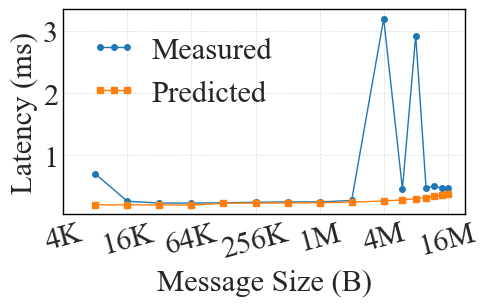

In [157]:
plot_latency_comparison(
    df=df_sweep_data_ll128_tree_v1,
    y_cols=['latency (us)', 'latency_pre (us)'],
    labels=['Measured', 'Predicted'],
    markers=['o', 's'],
    colors=['#1f77b4', '#ff7f0e'],
    xlabel='Message Size (B)',
    ylabel='Latency (ms)',
    pdf_filename='allreduce_tree_ll128_pre_comparison_v1.pdf' 
)

📄 Plot saved to: allreduce_tree_ll128_BW_pre_comparison_v1.pdf


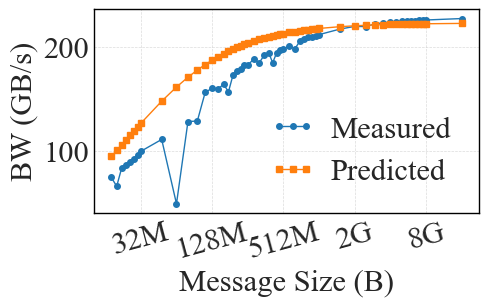

In [158]:
plot_BW_comparison(
    df=df_sweep_data_ll128_tree_v1,
    y_cols=['BW (GB/s)', 'BW_pre (GB/s)'],
    labels=['Measured', 'Predicted'],
    markers=['o', 's'],
    colors=['#1f77b4', '#ff7f0e'],
    xlabel='Message Size (B)',
    ylabel='BW (GB/s)',
    pdf_filename='allreduce_tree_ll128_BW_pre_comparison_v1.pdf' 
)

In [159]:
df_sweep_data_ll128_tree = df_sweep_data_means.filter(
    (pl.col("algorithm") == "tree") & 
    (pl.col("protocol") == "ll128") & 
    (pl.col("msg") == 17179869184) &
    (pl.col("nnodes") > 2) 
)

print(df_sweep_data_ll128_tree)

shape: (8, 6)
┌─────────────┬────────┬───────────┬──────────┬───────────────┬────────────┐
│ msg         ┆ nnodes ┆ algorithm ┆ protocol ┆ latency (us)  ┆ BW (GB/s)  │
│ ---         ┆ ---    ┆ ---       ┆ ---      ┆ ---           ┆ ---        │
│ i64         ┆ i64    ┆ str       ┆ str      ┆ f64           ┆ f64        │
╞═════════════╪════════╪═══════════╪══════════╪═══════════════╪════════════╡
│ 17179869184 ┆ 4      ┆ tree      ┆ ll128    ┆ 148315.666667 ┆ 224.433333 │
│ 17179869184 ┆ 8      ┆ tree      ┆ ll128    ┆ 148527.666667 ┆ 227.726667 │
│ 17179869184 ┆ 16     ┆ tree      ┆ ll128    ┆ 149871.0      ┆ 227.47     │
│ 17179869184 ┆ 32     ┆ tree      ┆ ll128    ┆ 150428.666667 ┆ 227.523333 │
│ 17179869184 ┆ 48     ┆ tree      ┆ ll128    ┆ 150623.333333 ┆ 227.523333 │
│ 17179869184 ┆ 64     ┆ tree      ┆ ll128    ┆ 151572.666667 ┆ 226.246667 │
│ 17179869184 ┆ 96     ┆ tree      ┆ ll128    ┆ 152119.666667 ┆ 225.58     │
│ 17179869184 ┆ 128    ┆ tree      ┆ ll128    ┆ 150993.666667 

           msg  nnodes algorithm protocol   latency (us)   BW (GB/s)  latency_pre (us)  BW_pre (GB/s)  prediction_error (%)
0  17179869184       4      tree    ll128  148315.666667  224.433333     152862.034946     217.751887              3.065332
1  17179869184       8      tree    ll128  148527.666667  227.726667     152938.109350     221.153953              2.969442
2  17179869184      16      tree    ll128  149871.000000  227.470000     153014.183754     222.798319              2.097259
3  17179869184      32      tree    ll128  150428.666667  227.523333     153090.258158     223.564328              1.769338
4  17179869184      48      tree    ll128  150623.333333  227.523333     153134.758832     223.791516              1.667355
5  17179869184      64      tree    ll128  151572.666667  226.246667     153166.332562     223.891432              1.051420
6  17179869184      96      tree    ll128  152119.666667  225.580000     153210.833236     223.972407              0.717308
7  17179

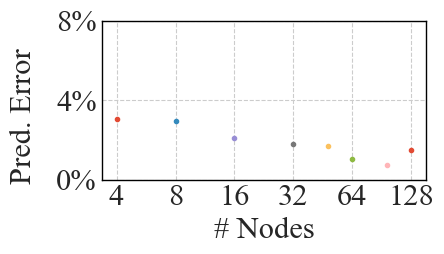

In [160]:
# use last chunk's T0 as the total communication time to calculate the G, only use the G to predict the latency when only consider the inter node latency.

gpus_per_node = 8
chunk_size_LL128 = 0.5487674169 # MB
number_channels = 16

# In the LL128 protocol, I discovered that the reduce/copy time for the first chunk is not needed, 
# as LL128 protocol appears to skip this operation. 
# In contrast, the Simple protocol requires this operation, 
# as evidenced by the reduceCopy() function in primitives_simple.h.
df_sweep_data_ll128_tree_v1 = df_sweep_data_ll128_tree.with_columns([
    (pl.when(pl.col("msg") < 131072)
     .then(
         # Small message case
         ((pl.min_horizontal(chunk_size_LL128*number_channels, pl.col("msg")/1e6) * 1e3 * 
           ((G_rrs_reverse_small_LL128 + G_rcs_reverse_small_LL128) * (pl.col("nnodes").log(2)-1) + G_send_reverse_small_LL128 + G_rrcs_reverse_small_LL128)) 
          + L_send_small_LL128 + (pl.col("nnodes").log(2)-1) * (L_rrs_small_LL128 + L_rcs_small_LL128) + L_rrcs_small_LL128
          + pl.max_horizontal(pl.col("msg")/1e6 - number_channels * chunk_size_LL128, 0) * 1e3 / G_LL128_small)
     )
     .otherwise(
         # Large message case
         ((pl.min_horizontal(chunk_size_LL128*number_channels, pl.col("msg")/1e6) * 1e3 * 
           ((G_rrs_reverse_large_LL128 + G_rcs_reverse_large_LL128) * (pl.col("nnodes").log(2)-1) + G_send_reverse_large_LL128 + G_rrcs_reverse_large_LL128)) 
          + L_send_large_LL128 + (pl.col("nnodes").log(2)-1) * (L_rrs_large_LL128 + L_rcs_large_LL128) + L_rrcs_large_LL128
          + pl.max_horizontal(pl.col("msg")/1e6 - number_channels * chunk_size_LL128, 0) * 1e3 / G_LL128_large)
     )).alias("latency_pre (us)")
])

# Then, create the bandwidth column using the newly created latency column
df_sweep_data_ll128_tree_v1 = df_sweep_data_ll128_tree_v1.with_columns([
    (pl.col("msg") * 0.001 * (2*(pl.col("nnodes") * gpus_per_node - 1)/(pl.col("nnodes") * gpus_per_node)) / pl.col("latency_pre (us)")).alias("BW_pre (GB/s)")
])

# Then, create the bandwidth column using the newly created latency column
df_sweep_data_ll128_tree_v1_csv = df_sweep_data_ll128_tree_v1.with_columns([
    ((pl.col("latency_pre (us)") - pl.col("latency (us)")).abs() * 100 / pl.col("latency (us)")).alias("prediction_error (%)")
])

with pd.option_context('display.max_rows', None, 'display.max_columns', None, 'display.width', 1000):
        print(df_sweep_data_ll128_tree_v1_csv.to_pandas())

df_sweep_data_ll128_tree_v1_csv.to_pandas().to_csv('model0.csv', index=False)

plot_prediction_error_nodes(
    df_sweep_data_ll128_tree_v1,
    figsize=(5, 3),
    pdf_filename="allreduce_tree_LL128_pre_error_v1_nodes.pdf",
    y_ticks=[0.0, 0.04, 0.08],
    y_labels=["0%", "4%", "8%"],
    xlabel="# Nodes",
    ylabel="Pred. Error",
    legend=False
)

📄 Plot saved to: allreduce_tree_ll128_pre_comparison_v1_nodes.pdf


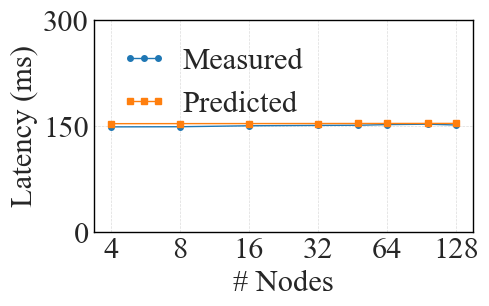

In [161]:
plot_latency_comparison_nodes(
    df=df_sweep_data_ll128_tree_v1,
    y_cols=['latency (us)', 'latency_pre (us)'],
    labels=['Measured', 'Predicted'],
    markers=['o', 's'],
    colors=['#1f77b4', '#ff7f0e'],
    xlabel='# Nodes',
    ylabel='Latency (ms)',
    pdf_filename='allreduce_tree_ll128_pre_comparison_v1_nodes.pdf',
    protocol="LL128"
)